In [1]:
import datetime as dt
import importlib
import joblib
import matplotlib.pyplot as plt
import multiprocessing as mp
import numpy as np
import os
import pandas as pd
import pathlib
import pymoo
import sklearn
import sys
import time
import utils._lib as lib
import xgboost as xgb
import warnings

warnings.filterwarnings("ignore")

# import some one offs
from multiprocessing.pool import ThreadPool
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.algorithms.soo.nonconvex.ga import GA
from pymoo.core.problem import ElementwiseProblem
from pymoo.core.problem import StarmapParallelization
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.optimize import minimize
from pymoo.problems import get_problem
from pymoo.visualization.scatter import Scatter
from typing import *



In [2]:


dir_git = "/Users/usuario/git/sisepuede"
if dir_git not in sys.path:
    sys.path.append(dir_git)
    
import sisepuede as sp
import sisepuede.core.attribute_table as att
import sisepuede.core.support_classes as sc
import sisepuede.manager.sisepuede_examples as sxl
import sisepuede.manager.sisepuede_file_structure as sfs
import sisepuede.manager.sisepuede_models as sm
import sisepuede.visualization.plots as spp
import sisepuede.transformers as trf
import sisepuede.utilities._plotting as spu
import sisepuede.utilities._toolbox as sf


log = None


In [3]:
##  GET FILE STRUCTURE AND ORGANIZING DATA

importlib.reload(sfs.ma)
importlib.reload(sfs)
_SISEPUEDE_FILE_STRUCTURE = sfs.SISEPUEDEFileStructure(
    initialize_directories = False, 
)

examples = sxl.SISEPUEDEExamples()
matt = _SISEPUEDE_FILE_STRUCTURE.model_attributes
regions = sc.Regions(matt, )
time_periods = sc.TimePeriods(matt, )


path_transformations = pathlib.Path("/Users/usuario/git/ssp_uganda_data/data_processing/transformations")
path_data = path_transformations.joinpath("input_data_uganda_base.csv")
df_input = pd.read_csv(path_data)

attribute_time_period = att.AttributeTable(
    path_transformations.joinpath("attribute_dim_time_period.csv"),
    matt.dim_time_period,
)


##  GET STRATEGIES

transformations = trf.Transformations(
    path_transformations, 
    attr_time_period = attribute_time_period,
    df_input = df_input,
)
transformers = transformations.transformers
strategies = trf.Strategies(
    transformations,
    export_path = "transformations",
    prebuild = False,
)




# initialize a SISEPUEDE object for the manager
sisepuede = sp.SISEPUEDE(
    "calibrated",
    attribute_time_period = attribute_time_period,
    db_type = "csv",
    id_str = "sisepuede_run_2026-03-10t13:27:53.264959",     # id_str = "sisepuede_run_2025-10-01T22:53:01.134831",
    initialize_as_dummy = False,                             # no connection to Julia is initialized if set to True
    logger = log,
    n_trials = 10000,
    regions = list(df_input[regions.key].unique()),          # use default region from examples
    strategies = strategies,
    try_exogenous_xl_types_in_variable_specification = False,
)

log = sisepuede.logger

2026-03-31 09:09:57,798 - INFO - Successfully initialized SISEPUEDEFileStructure.
2026-03-31 09:09:57,800 - WARNING - Missing key dict_dimensional_keys: key time_series not found. Tables that rely on the time_series will not have index checking.
2026-03-31 09:09:57,800 - INFO - 	Setting export engine to 'csv'.
2026-03-31 09:09:57,800 - DEBUG - Trying to get columns for ANALYSIS_METADATA from table at /Users/usuario/git/sisepuede/sisepuede/out/sisepuede_run_2026-03-10t13;27;53.264959/sisepuede_run_2026-03-10t13;27;53.264959_output_database/ANALYSIS_METADATA.csv.
2026-03-31 09:09:57,802 - INFO - Table ANALYSIS_METADATA found at /Users/usuario/git/sisepuede/sisepuede/out/sisepuede_run_2026-03-10t13;27;53.264959/sisepuede_run_2026-03-10t13;27;53.264959_output_database/ANALYSIS_METADATA.csv; it will not be replaced.
2026-03-31 09:09:57,802 - INFO - 	Columns successfully retrieved.
2026-03-31 09:09:57,802 - WARNING - No index fields defined. Index field values will not be checked when writin

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


Precompiling NemoMod...
Info Given NemoMod was explicitly requested, output will be shown live 
ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.
   4170.3 ms  ? NemoMod
[ Info: Precompiling NemoMod [a3c327a0-d2f0-11e8-37fd-d12fd35c3c72] 
ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.
┌ Info: Skipping precompilation due to precompilable error. Importing NemoMod [a3c327a0-d2f0-11e8-37fd-d12fd35c3c72].
└   exception = Error when precompiling module, potentially caused by a __precompile__(false) declaration in the module.
2026-03-31 09:11:14,449 - INFO - Successfully initialized JuMP optimizer from solver module HiGHS.
2026-03-31 09:11:14,462 - INFO - Successfully initialized SISEPUEDEModels.
2026-03-31 09:11:14,463 - WARNING - WARNING: re-initialization from analyis id requires addition coding to facilitate the re-generation 

In [ ]:
%load_ext autoreload
%autoreload 2

In [21]:
#####################
#    SET GLOBALS    #
#####################

# fields
_FIELD_FIELD = "field"
_FIELD_FUTURE_ID = "future_id"
_FIELD_PRIMARY_ID = "primary_id"
_FIELD_PARETO_INDEX = "pareto_index"
_FIELD_TRAJGROUP = "variable_trajectory_group"

# file names
_FILE_NAME_COLUMNS_TARG = "model_targets_column_ordering.csv"
_FILE_NAME_DATA_TRAINING = "training_data_cleaned.csv"
_FILE_NAME_MODEL = "xgb_pipeline.pkl"
_FILE_NAME_TRAJGROUPS_L = "VARIABLE_TRAJECTORY_GROUPS_L.csv"
_FILE_NAME_TRAJGROUPS_X = "VARIABLE_TRAJECTORY_GROUPS_X.csv"

# set some paths
_PATH_SCRIPT = pathlib.Path(os.getcwd())
_PATH_ROOT = _PATH_SCRIPT.parents[0]
_PATH_DATA = _PATH_ROOT.joinpath("data")
_PATH_DATA_MAPPING = _PATH_DATA.joinpath("mapping")
_PATH_DATA_TRAINING = _PATH_DATA.joinpath("training")
_PATH_PARETOS = _PATH_DATA.joinpath("iterative_paretos_20251119")
_PATH_TRAINED_MODELS = _PATH_SCRIPT.joinpath("trained_models")

# dependent paths
_PATH_DATA_COLS = _PATH_TRAINED_MODELS.joinpath(_FILE_NAME_COLUMNS_TARG)
_PATH_DATA_TRAINED = _PATH_TRAINED_MODELS.joinpath(_FILE_NAME_DATA_TRAINING)

#training_df = pd.read_csv(_PATH_DATA_TRAINED)
#training_df = training_df.drop(columns=["primary_id", "future_id"])
#training_df.head()

########################
#    SOME FUNCTIONS    #
########################

def get_fields_levers(
    df_training: pd.DataFrame,
    seed: int = 42,
) -> Tuple[List, Dict]:
    """Get the fields associated with Ls and associated dictionary of
        thresholds for constrained optimization.
    """

    fields_l = [x for x in df_training.columns if "_L_" in x]
    
    ##  GET FRACTIONS (RANDOM)
    # Source - https://stackoverflow.com/a/74474377
    # https://stackoverflow.com/questions/74469039/is-it-possible-to-change-the-seed-of-a-random-generator-in-numpy
    # Posted by Sam Mason
    # Retrieved 2026-02-04, License - CC BY-SA 4.0
    
    rng = np.random.default_rng()
    BitGen = type(rng.bit_generator)
    rng.bit_generator.state = BitGen(seed).state
    
    # generate a random float
    fracs = rng.random(len(fields_l))
    
    # get the BitGenerator used by default_rng and use the state from a fresh bit generator
    tups = [(0.0, 0.4*x + 0.2) for x in fracs]
    dict_l_to_conditional_implementation_level = dict(zip(fields_l, tups, ))


    out = (
        fields_l,
        dict_l_to_conditional_implementation_level,
    )

    return out



def get_fixed_fields_ind_dict(
    dict_training_data: Dict[str, Any],
) -> Dict[str, int]:
    """Build dictionary mapping the field to the associated index
        in vector x. This is a slow, lazy way to do it, but it works.
    """

    # get training data
    df_train = dict_training_data.get("df")
    if not isinstance(df_train, pd.DataFrame):
        raise TypeError(f"DataFrame 'df' not found in dict_training_data")
    
    labels_x = dict_training_data.get("fields_x")
    dict_inds_fixed = dict(
        (x, i) for i, x in enumerate(labels_x) if "_X_" in x
    )


    return dict_inds_fixed



def get_training_data(
) -> Dict[str, Any]:
    """Get the DF that was used to train 
    """

    # get the training data
    df_out = pd.read_csv(_PATH_DATA_TRAINED, )
    
    # get the training data column
    df_column_ordering = pd.read_csv(_PATH_DATA_COLS, )
    fields_y = df_column_ordering[_FIELD_FIELD].to_numpy()

    (
        fields_l,
        dict_l_to_conditional_implementation_level,
    ) = get_fields_levers(df_out, )

    fields_x = [x for x in df_out if x not in fields_y]

    dict_out = {
        "df": df_out,
        "fields_l": fields_l,
        "fields_x": fields_x,
        "fields_y": fields_y,
        "dict_fields_x_to_max_implementation": dict_l_to_conditional_implementation_level,
    }

    return dict_out

    

def get_model(
    fn: str = _FILE_NAME_MODEL,
) -> pd.DataFrame:
    """Get and prepare training data that was used to train the model
    """
    # set the read path
    path_model = _PATH_TRAINED_MODELS.joinpath(fn)
    xgb_pipeline = None
    
    try:
        xgb_pipeline = joblib.load(path_model)
        
    except Exception as e:
        raise RuntimeError(f"Unable to read xgb_pipeline at path '{path_model}': {e}")

    return xgb_pipeline


# retrieve 
dict_training_data = get_training_data()
xgb_pipeline = get_model()

df_train = dict_training_data.get("df")


/opt/miniconda3/envs/amber_is_your_energy/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator MultiOutputRegressor from version 1.7.2 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/miniconda3/envs/amber_is_your_energy/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.7.2 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [8]:

df_train = dict_training_data.get("df")

# Predict using the trained model
predictions = xgb_pipeline.predict(
    np.array(
        [
            df_train[dict_training_data.get("fields_x")].iloc[3]
        ]
    )
)

print("Predictions for single row:")
for i, label in enumerate(dict_training_data.get("fields_y")):
    print(f"{label}: {predictions[0][i]:.4f}")





Predictions for single row:
emission_total: 7645.4600
consumer_savings_mean_y1: 2.7690
consumer_savings_mean_y2: 10.3458
consumer_savings_mean_y3: 21.7865
consumer_savings_max_y1: 5.6659
consumer_savings_max_y2: 15.0461
consumer_savings_max_y3: 28.2454
human_health_mean_y1: 2.2528
human_health_mean_y2: 8.1297
human_health_mean_y3: 16.9885
human_health_max_y1: 4.5091
human_health_max_y2: 11.7685
human_health_max_y3: 21.9867
technical_cost_mean_y1: -0.7981
technical_cost_mean_y2: -1.5493
technical_cost_mean_y3: -0.8115
technical_cost_max_y1: -0.1013
technical_cost_max_y2: -0.1270
technical_cost_max_y3: -0.6210
consumer_savings_overall_mean: 10.0724
human_health_overall_mean: 7.8991
technical_cost_overall_mean: -0.9127


In [33]:
_FIELD_COST = "technical_cost_mean_y1"
_FIELD_EMISSIONS = "emission_total"
w_cost = np.where(dict_training_data.get("fields_y") == _FIELD_COST, )[0]
w_emissions = np.where(dict_training_data.get("fields_y") == _FIELD_EMISSIONS, )[0]

costs = []
emissions = []
for i, row  in df_train.iterrows():
    predictions = xgb_pipeline.predict(
        np.array(
            [
                row[dict_training_data.get("fields_x")]
            ]
        )
    )
    emissions.append(predictions[0, w_emissions[0]])
    costs.append(predictions[0, w_cost[0]])
    

In [11]:
df_train[
    (df_train["technical_cost_overall_mean"] < -1)
    & (df_train["group_63_X_elasticity_ippu"] == -1)
]["group_8_L_NemoMod "].mean()

np.float64(0.5540986234906786)

<Axes: >

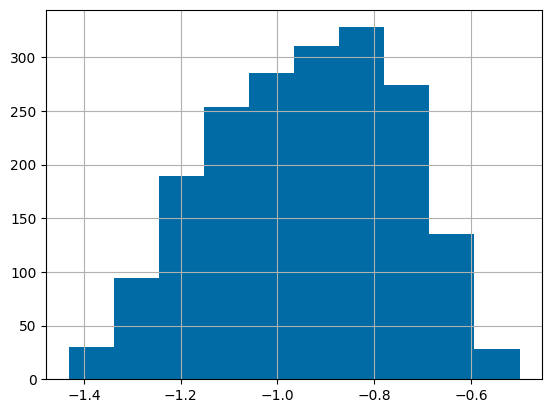

In [34]:
df_train["technical_cost_overall_mean"].hist()

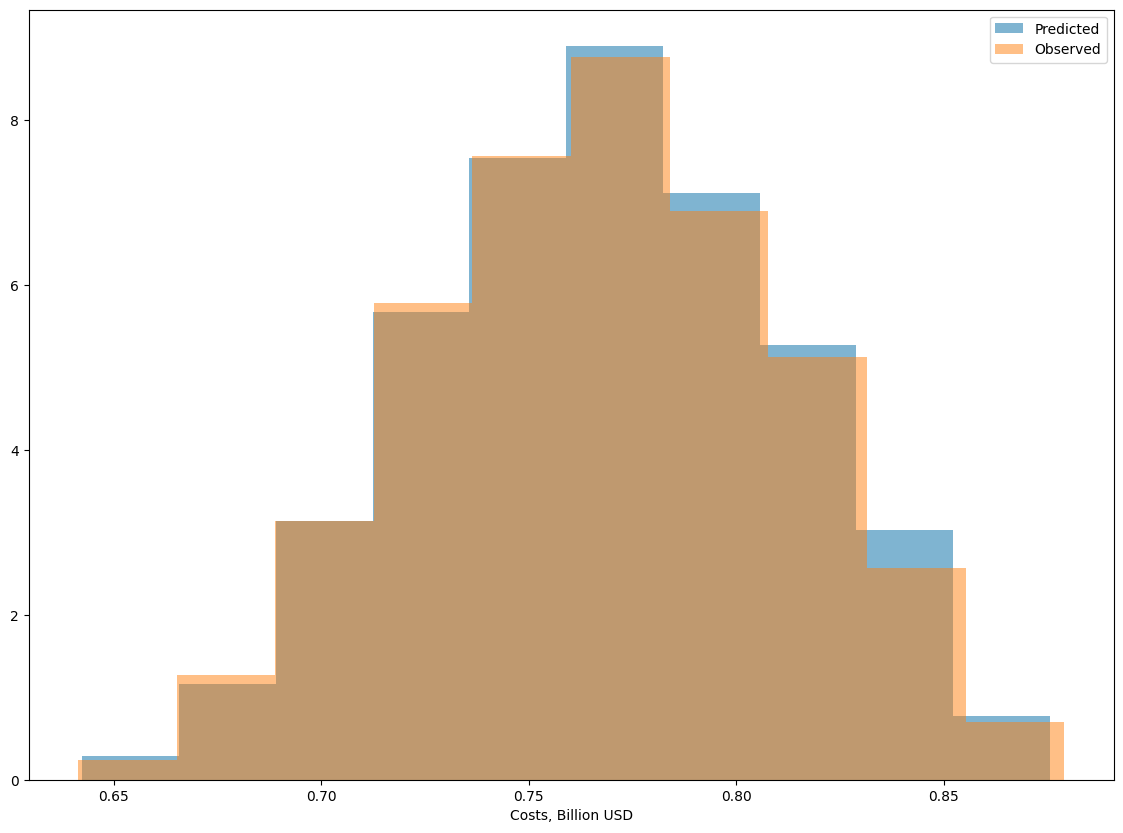

In [35]:
plt.style.use("default", )
plt.style.use("tableau-colorblind10", )

fig, ax = plt.subplots(figsize = (14, 10))

ax.hist(
    np.array(costs)*-1, 
    alpha = 0.5, 
    density = True,
    label = "Predicted", 
)

ax.hist(
    df_train["technical_cost_mean_y1"]*-1,
    alpha = 0.5,
    density = True,
    label = "Observed",
)

#ax.set_xlabel("Emissions, MT CO2e")
ax.set_xlabel("Costs, Billion USD")
ax.legend()

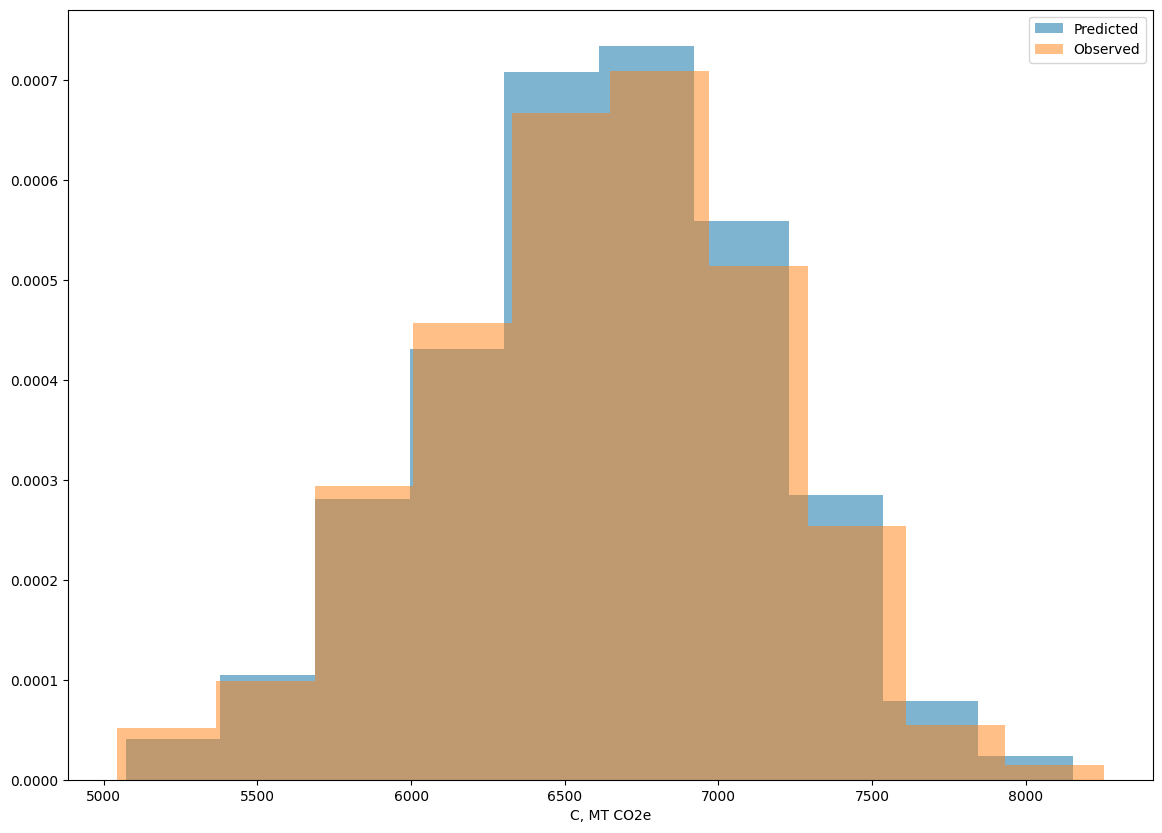

In [17]:
plt.style.use("default", )
plt.style.use("tableau-colorblind10", )

fig, ax = plt.subplots(figsize = (14, 10))

ax.hist(
    emissions, 
    alpha = 0.5, 
    density = True,
    label = "Predicted", 
)

ax.hist(
    df_train["emission_total"],
    alpha = 0.5,
    density = True,
    label = "Observed",
)

#ax.set_xlabel("Emissions, MT CO2e")
ax.set_xlabel("C, MT CO2e")
ax.legend()

In [18]:

df_train = dict_training_data.get("df")

# Predict using the trained model
predictions = xgb_pipeline.predict(
    np.array(
        [
            df_train[dict_training_data.get("fields_x")].iloc[0]
        ]
    )
)

print("Predictions for single row:")
for i, label in enumerate(dict_training_data.get("fields_y")):
    print(f"{label}: {predictions[0][i]:.4f}")





Predictions for single row:
emission_total: 7430.2090
consumer_savings_mean_y1: 2.5786
consumer_savings_mean_y2: 9.4128
consumer_savings_mean_y3: 19.6957
consumer_savings_max_y1: 5.2005
consumer_savings_max_y2: 13.6437
consumer_savings_max_y3: 25.4960
human_health_mean_y1: 2.2528
human_health_mean_y2: 8.1295
human_health_mean_y3: 16.9887
human_health_max_y1: 4.5091
human_health_max_y2: 11.7682
human_health_max_y3: 21.9869
technical_cost_mean_y1: -0.7544
technical_cost_mean_y2: -1.3649
technical_cost_mean_y3: -0.4362
technical_cost_max_y1: -0.1013
technical_cost_max_y2: 0.1085
technical_cost_max_y3: -0.3450
consumer_savings_overall_mean: 9.1492
human_health_overall_mean: 7.8992
technical_cost_overall_mean: -0.7387


In [382]:
import sisepuede.utilities._sql as squ
import sqlalchemy
engine = "/Users/usuario/git/sisepuede_data_pipeline/sisepuede_inputs.sqlite"
engine = sqlalchemy.create_engine(f"sqlite:///{engine}")

In [66]:
xgb_pipeline

,steps,"[('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,estimator,"XGBRegressor(...ree=None, ...)"
,n_jobs,None
,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None


# Setup Implementation Level optimization

In [42]:
class InvalidConstraint(Exception):
    pass



class ImplementationLevelProblem(ElementwiseProblem):
    """

    Intialization Arguments
    -----------------------
    model : sklearn.pipeline.Pipeline
        XGBoost meta model
    labels_x : Union[List, np.ndarray]
        Ordered vector of input labels to model
    labels_y : Union[List, np.ndarray]
        Ordered vector of output labels
    dict_upper_bounds : Dict
        Dictionary of upper bounds for implementation

    Optional Arguments
    ------------------
    arr_constraints_geq_y : Union[np.ndarray, None]
        Optional specification of a array of linear constraints to 
        pass to the optimizer. Constraints are entered as 

            np.array(
                [
                
                    [b0, c_01, c_02,..., c_0m],
                    [b1, c_11, c_12,..., c_1m],
                    ...
                ]
            )

        where b_i + np.dot(c_i, y) <= 0 is the constraint. This should be 
        entered in terms of y (filtered by inds_obj). 
            
    dict_fixed_inputs : Union[Dict[int, float], None]
        Optional specification of a dictionary of fixed values for inputs. 
        Maps the index in the input vector to a fixed value to maintain.
    inds_obj : Union[List, np.ndarray, None]
        Optional specification of indices in the output features to
        keep and optimize on. If None, searches for multi-dimensional 
        frontier associated with all outputs
    vec_obj_scalars : Union[List, np.ndarray, None]
        Optional scalars to apply to outputs. Must be same shape as
        output (i.e., if reducing using inds_obj, must be of same length)
    **kwargs : 
        Passed to super().__init__() (super => pymoo.Problem class)
    """
    
    def __init__(self,
        model: sklearn.pipeline.Pipeline,
        labels_x: Union[List, np.ndarray],
        labels_y: Union[List, np.ndarray],
        dict_bounds: Dict[str, Tuple[float]],
        arr_constraints_geq_y: Union[np.ndarray, None] = None,
        dict_fixed_inputs: Union[Dict[int, float], None] = None,
        inds_obj: Union[List, np.ndarray, None] = None,
        vec_obj_scalars: Union[List, np.ndarray, None] = None,
        **kwargs,
    ) -> None:

        self._initialize_model(model, )
        self._initialize_problem(
            arr_constraints_geq_y,
            dict_bounds,
            labels_x,
            labels_y,
            inds_obj,
            vec_obj_scalars,
            **kwargs,
        )

        self._initialize_fixed_inputs(
            dict_fixed_inputs,
        )
        
        
        return None


    

    ##################################
    #    INITIALIZATION FUNCTIONS    #
    ##################################

    def _initialize_constraints(self,
        arr_constraints_geq_y: Union[np.ndarray, None],
        m: int,
    ) -> None:
        """Verify that constraints are properly set. Must be called 
            after _initialize_problem(). Sets the following properties:

                * self.arr_constraints_geq_y
                * self.n_constraints_y
        """

        # initialize
        self.arr_constraints_geq_y = None
        self.n_constraints = 0
        self.n_constraints_x = 0
        self.n_constraints_y = 0

        
        ##  GET CONSTRAINTS

        if not isinstance(arr_constraints_geq_y, np.ndarray):
            return None

        # check shape
        if len(arr_constraints_geq_y.shape) != 2:
            raise InvalidConstraint(f"Constraints on y must be defined as a two-dimensional array")
            
        if arr_constraints_geq_y.shape[1] != m + 1:
            raise InvalidConstraint(f"Constraints on y should be an array with {m + 1} columns")

        n_constraints_y = arr_constraints_geq_y.shape[0]
        n_constraints = n_constraints_y    # option to add in some for x
        
        
        ##  SET PROPERTIES

        self.arr_constraints_geq_y = arr_constraints_geq_y
        self.n_constraints = n_constraints
        self.n_constraints_y = n_constraints_y
        
        return None


    
    def _initialize_fixed_inputs(self,
        dict_fixed_inputs: Union[Dict[int, float], None],
    ) -> None:
        """Check the model input and set property self.model
        """

        dict_fi = {}
        
        if isinstance(dict_fixed_inputs, dict):

            for k, v in dict_fixed_inputs.items():
                keep_q = isinstance(k, (int, np.int32, np.int64, ))
                keep_q &= isinstance(v, (int, np.int32, np.int64, float, np.float32, np.float64))
                keep_q &= k in range(self.n)
                
                if not keep_q: continue

                dict_fi.update({k: v})


        ##  SET PROPERTY
        
        self.dict_fixed_inputs = dict_fi

        return None


    
    def _initialize_model(self,
        model: sklearn.pipeline.Pipeline,
    ) -> None:
        """Check the model input and set property self.model
        """
        if not isinstance(model, sklearn.pipeline.Pipeline):
            tp = str(type(model))
            raise TypeError(f"Invalid type '{tp}' found for model. Must be of type sklearn.pipeline.Pipeline")


        self.model = model

        return None

    

    def _initialize_problem(self,
        arr_constraints_geq_y: Union[np.ndarray, None],
        dict_bounds: Dict[str, float],
        labels_x: Union[List, np.ndarray],
        labels_y: Union[List, np.ndarray],
        inds_obj: Union[List, np.ndarray, None],
        vec_obj_scalars: Union[List, np.ndarray, None],
        **kwargs,
    ) -> None:
        """Initialize scalars used in the problem
        """
        ##  INIT AND CONVERSION
        
        labels_x = np.array(labels_x, )
        labels_y_universe = np.array(labels_y, )

        # build bounds
        xl = np.zeros(labels_x.shape[0])
        xu = np.ones(labels_x.shape[0])

        dict_bounds = {} if not isinstance(dict_bounds, dict) else dict_bounds
        dict_inds = {}
        
        for i, k in enumerate(labels_x):
            # update indices
            dict_inds.update({k: ("x", i), })
            
            v = dict_bounds.get(k)
            
            # check validity
            skip = not isinstance(v, tuple)
            skip |= (len(v) != 2) if not skip else skip
            if not skip:
                skip |= (v[1] < v[0]) if (lib.isnumber(v[0]) & lib.isnumber(v[1])) else skip
                
            if skip: continue

            m0, m1 = v
            
            # update?
            if lib.isnumber(m0):
                xl[i] = min(max(m0, 0.0), 1.0)

            if lib.isnumber(m1):
                xu[i] = min(max(m1, 0.0), 1.0)
        

            
            

        # filter indices used in the objective function
        inds_obj = (
            np.arange(labels_y_universe.shape[0])
            if inds_obj is None
            else np.array(inds_obj).astype(int)
        )

        # check adjustments
        vec_obj_scalars = (
            np.array(vec_obj_scalars) 
            if vec_obj_scalars is not None 
            else vec_obj_scalars
        )
        
        vec_obj_scalars = (
            np.ones(inds_obj.shape, np.int64)
            if vec_obj_scalars is None
            else (
                np.ones(inds_obj.shape, np.int64)
                if vec_obj_scalars.shape != inds_obj.shape
                else vec_obj_scalars
            )
        )

        # set labels and some shapes
        labels_y = labels_y_universe[inds_obj]
        
        n = labels_x.shape[0]
        m = labels_y.shape[0]
        m_universe = labels_y_universe.shape[0]
        

        # set constraints
        self._initialize_constraints(
            arr_constraints_geq_y, 
            m_universe, 
        ) 

        
        ##  PASS TO SUPER

        super().__init__(
            n_var = n,
            n_obj = m,
            n_ieq_constr = self.n_constraints,   # set in _initialize_constraints()
            xl = xl,
            xu = xu,
            **kwargs,
        )


        ##  SET SOME PROPERTIES

        self.dict_inds = dict_inds
        self.inds_obj = inds_obj
        self.labels_x = labels_x
        self.labels_y = labels_y
        self.labels_y_universe = labels_y_universe    # all y values
        self.m = m                                    # size of output feature space
        self.m_universe = m_universe                  # size of all potential output features
        self.n = n                                    # size of input feature space
        self.vec_obj_scalars = vec_obj_scalars        # vector of scalars to multiply output predictions by (ordered by inds_obj)
        self.xl = xl                                  # vector of lower bounds
        self.xu = xu                                  # vector of upper bounds
        
        return None
    

    

    #########################
    #    CORE OPERATIONS    #
    #########################

    def build_input_vector(self,
        x: np.ndarray,
    ) -> np.ndarray:
        """Build the input vector for the XGBoost pipeline
        """

        for k, v in self.dict_fixed_inputs.items():
            x[k] = v

        out = np.array([x])
        
        return out



    def _clean_input_array(self,
        x: np.ndarray,
    ) -> np.ndarray:
        """Modify an input array (each row is an input vector X) to pass 
            fixed inputs.
        """
        # no action here
        if len(x.shape) not in [1, 2]:
            return x

        for k, v in self.dict_fixed_inputs.items():
            if len(x.shape) == 1:
                x[k] = v
            else:
                x[:, k] = v
        
        return x
    
        
    
    def _evaluate(self,
        x: np.ndarray,
        out: dict,
        *args, 
        **kwargs,
    ) -> None:
        """This method is required for the pymoo.minimize() function
        """
        # treat any fixed inputs
        x_in = self.build_input_vector(x)
        
        # predict the outcome; both dimensions will be minimized
        arr = self.model.predict(x_in, )     # [...., emission, savings, ...]
        vec = arr[0, self.inds_obj]          # [emission, savings]
        vec *= self.vec_obj_scalars          # [emission, cost]            
        
        out["F"] = vec

        # set the constraints--need to add back in the objective scalar modifications
        vec_constraint = arr[0].copy()
        np.put(vec_constraint, self.inds_obj, vec)
        self._set_constrants(x, vec_constraint, out, )

        return None



    def _set_constrants(self,
        x: np.ndarray,
        y: np.ndarray,
        out: dict,
    ) -> None:
        """Update constraints for candidate x and output out
        """

        # if no constraints are set, move on
        if self.arr_constraints_geq_y is None:
            return None


        # otherwise, initialize list and iterate
        constraints = []
        
        for i in range(self.n_constraints_y):

            constr = np.dot(
                y, 
                self.arr_constraints_geq_y[i, 1:]
            )
            constr += self.arr_constraints_geq_y[i, 0]
            
            constraints.append(constr)

        out["G"] = constraints

        return None




##  SET UP CONSTRAINTS
# try to set up with technical_cost_overall_mean > -1.1 (see hist below comparing average lever intensity by average cost)

fields_y = dict_training_data.get("fields_y")
ind = np.where(fields_y == "technical_cost_overall_mean")
ind = ind[0][0]

arr_constraints_geq_y = np.zeros((1, fields_y.shape[0] + 1))

# has to be written in form b_i + np.dot(c_i, y) <= 0 => np.dot(c_i, y) <= b_i
b_i = -1.1                          # hypothetical cost max
arr_constraints_geq_y[0, 0] = b_i
arr_constraints_geq_y[0, ind] = 1

# to turn into np.dot(c_i, y) >= b_i, mult by -1
arr_constraints_geq_y[0] *= -1


##  GET FIXED INPUTS

dict_fixed_inputs = get_fixed_fields_ind_dict(dict_training_data, )




# constraints entered as g(x) <= 0; multiple constraints are set as a a list
problem_soo = ImplementationLevelProblem(
    xgb_pipeline, 
    dict_training_data.get("fields_x"),
    dict_training_data.get("fields_y"),
    dict_training_data.get("dict_fields_x_to_max_implementation"),
    arr_constraints_geq_y = arr_constraints_geq_y,
    dict_fixed_inputs = dict_fixed_inputs,
    inds_obj = [0],#[0, 4],                       # indices of output values to actually optimize on
    vec_obj_scalars = np.array([1]),#, -1]),      # scalars to apply to output values (ordered same as inds_obj)
    #elementwise_runner = runner,             # use this to parallelize (doesn't work that well--not sure why I can't pass directly to NSGA())
)




In [43]:
df1 = df[df["technical_cost_overall_mean"] > -0.7]
df2 = df[df["technical_cost_overall_mean"] < -1.2]

fig, ax = plt.subplots(figsize = (12, 7))

df1[dict_training_data.get("fields_l")].mean(axis = 1).hist(ax = ax, label = "higher val of tech cost")
df2[dict_training_data.get("fields_l")].mean(axis = 1).hist(ax = ax, label = "lower val of tech cost")

ax.legend()

NameError: name 'df' is not defined

In [64]:
arr_constraints_geq_y


array([[ 1.1, -0. , -0. , -0. , -0. , -0. , -0. , -0. , -0. , -0. , -0. ,
        -0. , -0. , -0. , -0. , -0. , -0. , -0. , -0. , -0. , -0. , -1. ,
        -0. ]])

In [ ]:
t0 = time.time()

algorithm = GA(
    pop_size=100,
    eliminate_duplicates=True)


res = minimize(problem_soo,
               algorithm,
               seed=1,
               verbose=False)


t1 = time.time()
t_elapse = np.round(t1 - t0, decimals = 2)
print(f"Best solution found in {t_elapse} seconds: \nX = {res.X}\nF = {res.F}")




In [47]:
print(f"Best solution found in {t_elapse} seconds: \nX = {res.X}\nF = {res.F}")


Best solution found in 54.18 seconds: 
X = [0.36227813 0.07803646 0.01039927 0.06153935 0.77405646 0.61359395
 0.20343655 0.567044   0.49751732 0.44040425 0.05091252 0.33607465
 0.11976768 0.02946649 0.30720339 0.43641795 0.34287693 0.20941553
 0.37642417 0.94060923 0.83093914 0.02144942 0.09472124 0.18270906
 0.27489773 0.3191105  0.10838952 0.55349949 0.01284602 0.04403198
 0.334925   0.06879376 0.07151832 0.06848918 0.36027118 0.03034651
 0.17631531 0.17694125 0.16815322 0.21142738 0.17061493 0.0318332
 0.02649692 0.24324073 0.25677162 0.42193473 0.1483249  0.2534974
 0.14282105 0.02518143 0.42864931 0.44116237 0.0807552  0.01815562
 0.01517039 0.29569181 0.99508928 0.28856877 0.02191198 0.04612661
 0.14434894 0.48927335 0.1816801  0.46260986 0.09787126 0.378738
 0.40583816 0.20993091]
F = [5484.87207031]


1744.186046511628

In [67]:
dict_training_data.get("fields_x")

['group_29_L_Fraction Eating Red Meat',
 'group_48_L_Biogas Recovery Factor at Wastewater Treatment Plants',
 'group_58_L_Fraction of Non-Recycled Solid Waste ',
 'group_9_L_',
 'group_63_X_elasticity_ippu',
 'group_66_X_elasticity_scoe_enerdem_per',
 'group_51_L_Treatment Fraction ',
 'group_34_L_SCOE Fraction Heat Energy Demand ',
 'group_2_L_Fraction of Food Produced Lost Before Consumption',
 'group_56_L_Fraction of Landfill Gas Recovered for Energy',
 'group_59_L_Fraction of Waste Recycled',
 'group_23_L_Biogas Recovery Factor at LSMM Anaerobic Facilities',
 'group_53_L_Waste Per Capita Scale Factor',
 'group_38_L_Electrical Vehicle Efficiency',
 'group_42_L_Transportation Mode Fuel Fraction ',
 'group_25_L_Livestock Manure Management Fraction ',
 'group_26_L_Livestock Manure Management Fraction ',
 'group_57_L_Fraction of ',
 'group_55_L_Fraction of Landfill Gas Recovered at Landfills',
 'group_61_X_cost_enfu_fuel',
 'group_68_X_elasticity_trde_pkm_to_gdppc',
 'group_5_L_Annual C

In [56]:
dict_training_data.get("fields_y")[13]

'technical_cost_mean_y1'

In [60]:
out = xgb_pipeline.predict([res.X])
out[0, 13]*-1

np.float32(0.6875643)

In [61]:
inds_neg_one = [i for i, x in enumerate(dict_training_data.get("fields_x")) if "_X_" in x]
arr = np.ones(res.X.shape)[None,...]
arr[0, inds_neg_one] = -1

problem_soo.model.predict(arr, )




array([[ 5.66806982e+03,  3.35259986e+00,  1.31181602e+01,
         2.83764496e+01,  7.09951258e+00,  1.92654896e+01,
         3.72402496e+01,  2.25276589e+00,  8.12962341e+00,
         1.69884777e+01,  4.50913811e+00,  1.17677860e+01,
         2.19875298e+01, -8.61186445e-01, -1.87120330e+00,
        -1.70859301e+00, -1.01327054e-01, -5.87159276e-01,
        -1.23326492e+00,  1.28712645e+01,  7.89925575e+00,
        -1.25619042e+00]], dtype=float32)

In [193]:
df_test = pd.DataFrame(
    dict(
        (x, [res.X[i]]) for i, x in enumerate(dict_training_data.get("fields_x"))
    )
)


df_test.transpose().reset_index().to_csv("~/Desktop/tmp.csv", encoding = "UTF-8", index = None,)




In [188]:
problem_soo.model.predict(np.array([res.X]))[0,21]




np.float32(-0.5860203)

In [78]:
#?pymoo.core.problem.Problem
plot = Scatter()
plot.add(problem.pareto_front(), plot_type="line", color="black", alpha=0.7)
plot.add(res.F, facecolor="none", edgecolor="red")
plot.show()

NameError: name 'problem' is not defined

In [386]:
# some parallelization code blocks
"""
# if __name__ == "__main__":
    
    # with mp.Pool(processes = 6, ) as pool:
    #     runner = StarmapParallelization(pool.starmap, )
    #     elementwise_runner = runner,    # add to NarrativePareto as kwarg
 
t0 = time.time()
#with ThreadPool(20, ) as pool:
#    runner = StarmapParallelization(pool.starmap, )

from dask.distributed import Client
from pymoo.core.problem import DaskParallelization
client = Client()
client.restart()
print("DASK STARTED")
runner = DaskParallelization(client)
"""

'\n# if __name__ == "__main__":\n\n    # with mp.Pool(processes = 6, ) as pool:\n    #     runner = StarmapParallelization(pool.starmap, )\n    #     elementwise_runner = runner,    # add to NarrativePareto as kwarg\n\nt0 = time.time()\n#with ThreadPool(20, ) as pool:\n#    runner = StarmapParallelization(pool.starmap, )\n\nfrom dask.distributed import Client\nfrom pymoo.core.problem import DaskParallelization\nclient = Client()\nclient.restart()\nprint("DASK STARTED")\nrunner = DaskParallelization(client)\n'

In [ ]:
dict_training_data.get("dict_fields_x_to_max_implementation")

In [108]:
?ImplementationLevelProblem

Init signature:
ImplementationLevelProblem(
    model: sklearn.pipeline.Pipeline,
    labels_x: Union[List, numpy.ndarray],
    labels_y: Union[List, numpy.ndarray],
    dict_bounds: Dict[str, Tuple[float]],
    dict_fixed_inputs: Optional[Dict[int, float]] = None,
    inds_obj: Union[List, numpy.ndarray, NoneType] = None,
    vec_obj_scalars: Union[List, numpy.ndarray, NoneType] = None,
    **kwargs,
) -> None
Docstring:     
Intialization Arguments
-----------------------
model : sklearn.pipeline.Pipeline
    XGBoost meta model
labels_x : Union[List, np.ndarray]
    Ordered vector of input labels to model
labels_y : Union[List, np.ndarray]
    Ordered vector of output labels
dict_upper_bounds : Dict
    Dictionary of upper bounds for implementation

Optional Arguments
------------------
dict_fixed_inputs : Union[Dict[int, float], None]
    Optional specification of a dictionary of fixed values for inputs. 
    Maps the index in the input vector to a fixed value to maintain.
inds_obj 

In [89]:
from pymoo.algorithms.soo.nonconvex.ga import GA

In [91]:
from pymoo.algorithms.soo.nonconvex.ga import GA
from pymoo.problems import get_problem
from pymoo.optimize import minimize

#problem = get_problem("g1")

algorithm = GA(
    pop_size=100,
    eliminate_duplicates=True)

res = minimize(problem,
               algorithm,
               seed=1,
               verbose=False)

print("Best solution found: \nX = %s\nF = %s" % (res.X, res.F))

Best solution found: 
X = [0.98919497 0.91152675 0.28890593 0.76575722 0.62730526 0.39793875
 0.43470477 0.93948663 0.8652382  0.99396063 0.32151928 0.38885205
 0.88644954 0.64704555 0.041044   0.02215284 0.65778067 0.50625709
 0.87488944 0.52901813 0.45914368 0.61593419 0.97965677 0.09328926
 0.79319552 0.64616626 0.67239541 0.94179823 0.6111119  0.53138849
 0.9174581  0.07306506 0.20293028 0.53401468 0.33474544 0.83043753
 0.82551242 0.1097319  0.7475554  0.20211307 0.52835474 0.47394111
 0.08979937 0.49619127 0.13391518 0.77105541 0.41461412 0.25130171
 0.86686709 0.4456916  0.49066149 0.4340059  0.0269722  0.21587895
 0.01906266 0.1697816  0.71195745 0.80652666 0.78253776 0.03794371
 0.11519008 0.43884469 0.89338727 0.2087802  0.33832479 0.99948038
 0.65469013 0.97394645]
F = [4676.82714844]


In [102]:
?minimize

Signature:
minimize(
    problem,
    algorithm,
    termination=None,
    copy_algorithm=True,
    copy_termination=True,
    **kwargs,
)
Docstring:
Minimization of function of one or more variables, objectives and constraints.

This is used as a convenience function to execute several algorithms with default settings which turned
out to work for a test single. However, evolutionary computations utilizes the idea of customizing a
meta-algorithm. Customizing the algorithm using the object-oriented interface is recommended to improve the
convergence.

Parameters
----------

problem : :class:`~pymoo.core.problem.Problem`
    A problem object which is defined using pymoo.

algorithm : :class:`~pymoo.core.algorithm.Algorithm`
    The algorithm object that should be used for the optimization.

termination : :class:`~pymoo.core.termination.Termination` or tuple
    The termination criterion that is used to stop the algorithm.

seed : integer
    The random seed to be used.

verbose : bool
  

In [95]:
dict_training_data.get("fields_x")#.index("group_8_L_NemoMod ")

['group_29_L_Fraction Eating Red Meat',
 'group_48_L_Biogas Recovery Factor at Wastewater Treatment Plants',
 'group_58_L_Fraction of Non-Recycled Solid Waste ',
 'group_9_L_',
 'group_63_X_elasticity_ippu',
 'group_66_X_elasticity_scoe_enerdem_per',
 'group_51_L_Treatment Fraction ',
 'group_34_L_SCOE Fraction Heat Energy Demand ',
 'group_2_L_Fraction of Food Produced Lost Before Consumption',
 'group_56_L_Fraction of Landfill Gas Recovered for Energy',
 'group_59_L_Fraction of Waste Recycled',
 'group_23_L_Biogas Recovery Factor at LSMM Anaerobic Facilities',
 'group_53_L_Waste Per Capita Scale Factor',
 'group_38_L_Electrical Vehicle Efficiency',
 'group_42_L_Transportation Mode Fuel Fraction ',
 'group_25_L_Livestock Manure Management Fraction ',
 'group_26_L_Livestock Manure Management Fraction ',
 'group_57_L_Fraction of ',
 'group_55_L_Fraction of Landfill Gas Recovered at Landfills',
 'group_61_X_cost_enfu_fuel',
 'group_68_X_elasticity_trde_pkm_to_gdppc',
 'group_5_L_Annual C

# Run Emissions/Cost tradeoff

In [20]:

def build_df_out(
    res: pymoo.core.result.Result,
    problem: NarrativePareto,
    dict_additional_fields: Union[Dict[str, Any], None] = None,
) -> pd.DataFrame:
    """Build an output dataframe
    """

    # initialize base DataFrame out
    df_base = pd.DataFrame(
        res.F,
        columns = problem.labels_y,
    )

    # add Xs
    df_out_lhs = pd.DataFrame(
        problem._clean_input_array(res.X),
        columns = problem.labels_x,
    )

    # concat
    df_base = pd.concat([df_out_lhs, df_base], axis = 1, )
    
    # add columns of interest
    df_base[_FIELD_PARETO_INDEX] = range(df_base.shape[0])
    if isinstance(dict_additional_fields, dict):
        for k, v in dict_additional_fields.items():
            if not isinstance(k, str): continue
            df_base[k] = v

    return df_base










##  SETUP THE ALGORITHM

algorithm = NSGA2(
    pop_size = 40,
    n_offsprings = 10,
    sampling = FloatRandomSampling(),
    crossover = SBX(prob = 0.9, eta = 15),
    mutation = PM(eta = 20),
    eliminate_duplicates = True,
)



##  INITIALIZE OUTPUT


# used to map fixed values to problem
dict_inds_fields_trajgroups_x = get_fixed_fields_ind_dict(
    dict_training_data,
    dict_trajgroups,
)
fields_trajgroups_x = sorted(list(dict_inds_fields_trajgroups_x.keys()))

# initialize output from the iteration
df_pareto_frontiers = []
dict_res = {}
# 403186


# some path manipulation and prep
overwrite_q = True
if not _PATH_PARETOS.is_dir():
    os.makedirs(_PATH_PARETOS, exist_ok = True, )

t0 = time.time()


with ThreadPool(30, ) as pool:

    runner = StarmapParallelization(pool.starmap, )
    
    for i, row in df_train.iterrows():
        
        # temporary specification to skip other rows
        if i > 0:
            continue

            
        # build export path and check
        future_id = int(row[_FIELD_FUTURE_ID])
        path_out = _PATH_PARETOS.joinpath(f"frontier_{future_id}.csv")
        if path_out.is_file() and not overwrite_q: continue 

        #if row["future_id"] not in [0, 784, 925]: continue 
        print(f"Starting row {i}, {_FIELD_FUTURE_ID} = {future_id}...")
        
        
        # get inputs
        dict_fixed_inputs = row[fields_trajgroups_x].to_dict()
        dict_fixed_inputs = dict(
            (dict_inds_fields_trajgroups_x.get(k), v)
            for k, v in dict_fixed_inputs.items()
        )
    
        # setup the problem
        problem = NarrativePareto(
            xgb_pipeline, 
            dict_training_data.get("fields_x"),
            dict_training_data.get("fields_y"),
            dict_fixed_inputs = dict_fixed_inputs,
            inds_obj = [0, 4],                       # indices of output values to actually optimize on
            vec_obj_scalars = np.array([1, -1]),      # scalars to apply to output values (ordered same as inds_obj)
            elementwise_runner = runner,             # use this to parallelize (doesn't work that well--not sure why I can't pass directly to NSGA())
        )
    
        # 
        res = minimize(
            problem,
            algorithm,
            ('n_gen', 1000),
            verbose = False,
        )

        # get the output dataframe
        df_cur = build_df_out(
            res,
            problem,
            dict_additional_fields = {
                _FIELD_FUTURE_ID: future_id, 
            }
        )

        df_cur.to_csv(
            path_out,
            encoding = "UTF-8",
            index = None,
        )

        # append to outputs
        df_pareto_frontiers.append(df_cur, )
        dict_res.update({i: res, })
        
        print(f"Row {i} done.\n\n")


df_pareto_frontiers = (
    pd.concat(df_pareto_frontiers)
    .reset_index(drop = True)
)

t1 = time.time()        




NameError: name 'NarrativePareto' is not defined

# Run an emissions, jobs



In [789]:


with ThreadPool(30, ) as pool:

    runner = StarmapParallelization(pool.starmap, )
    
    for i, row in df_train.iterrows():
        
        # temporary specification to skip other rows
        if i > 0:
            continue

            
        # build export path and check
        future_id = int(row[_FIELD_FUTURE_ID])
        path_out = _PATH_PARETOS.joinpath(f"frontier_{future_id}.csv")
        if path_out.is_file() and not overwrite_q: continue 

        #if row["future_id"] not in [0, 784, 925]: continue 
        print(f"Starting row {i}, {_FIELD_FUTURE_ID} = {future_id}...")
        
        
        # get inputs
        dict_fixed_inputs = row[fields_trajgroups_x].to_dict()
        dict_fixed_inputs = dict(
            (dict_inds_fields_trajgroups_x.get(k), v)
            for k, v in dict_fixed_inputs.items()
        )
    
        # setup the problem
        problem2 = NarrativePareto(
            xgb_pipeline, 
            dict_training_data.get("fields_x"),
            dict_training_data.get("fields_y"),
            dict_fixed_inputs = dict_fixed_inputs,
            inds_obj = [0, 6],                        # indices of output values to actually optimize on
            vec_obj_scalars = np.array([1, 1]),      # scalars to apply to output values (ordered same as inds_obj)
            elementwise_runner = runner,              # use this to parallelize (doesn't work that well--not sure why I can't pass directly to NSGA())
        )
    
        # 
        res2 = minimize(
            problem2,
            algorithm,
            ('n_gen', 1000),
            verbose = False,
        )

       
t1 = time.time()        

print(t1 - t0)


Starting row 0, future_id = 1...
29194.171637058258


Text(0, 0.5, 'Change in Jobs')

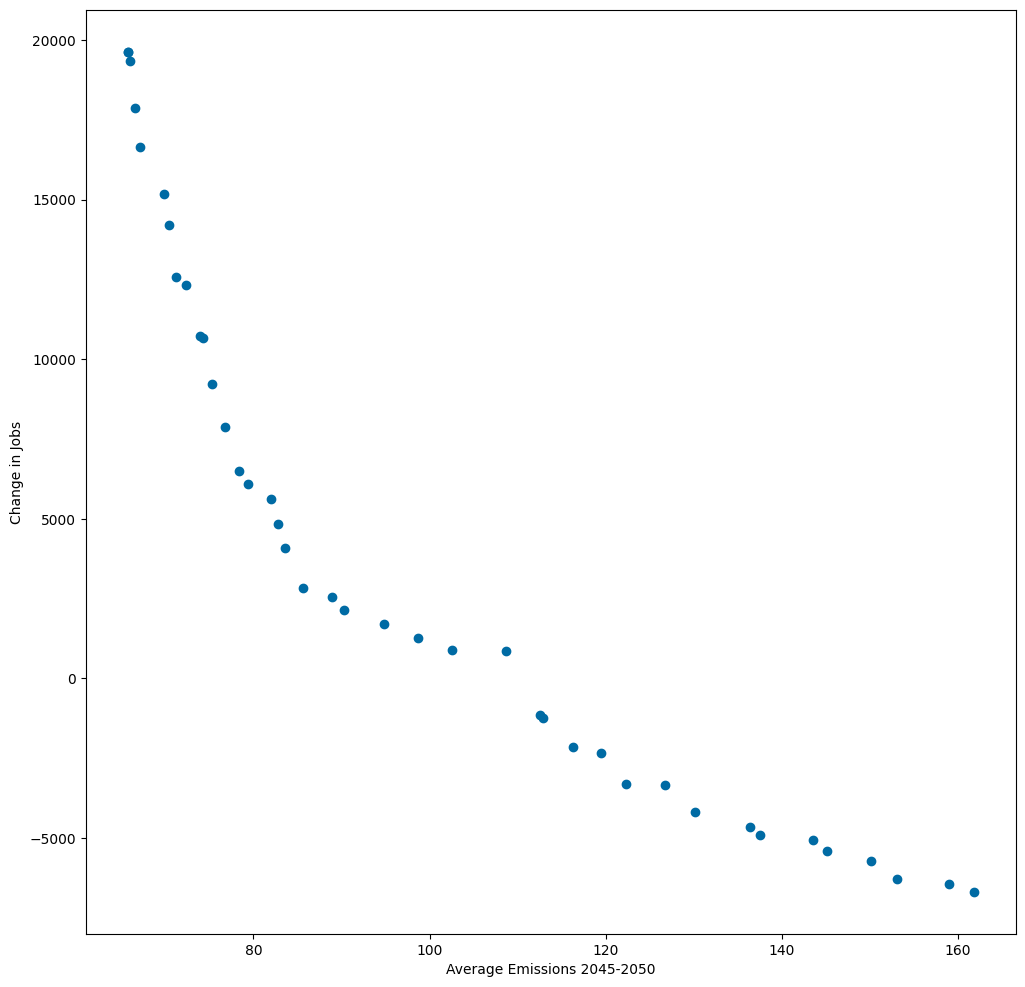

In [793]:
x = res2.F[:, 0]
y = res2.F[:, 1]

fig, ax = plt.subplots(figsize = (12, 12))
ax.scatter(x, y, )

ax.set_xlabel("Average Emissions 2045-2050")
ax.set_ylabel("Change in Jobs")

In [787]:
dict_training_data.get("fields_y")

['emission_avg_last_five_years',
 'emission_total',
 'production_total',
 'production_cost_total',
 'technical_cost',
 'air_pollution',
 'num_jobs',
 'average_salary_jobs_added']

In [518]:
dict_training_data.get("fields_x")[47]

'group_48_gdp_mmm_usd'

In [519]:
dict_fixed_inputs
fields_trajgroups_x

['group_47_cost_enfu_fuel',
 'group_48_gdp_mmm_usd',
 'group_49_scalar_inen_energy_demand_other_product_manufacturing',
 'group_50_elasticity_ippu',
 'group_51_elasticity_ippu_product_use',
 'group_52_population_gnrl',
 'group_53_elasticity_scoe_enerdem_per',
 'group_54_nemomod_enst_capital_cost_st',
 'group_55_nemomod_entc',
 'group_56_nemomod_entc',
 'group_57_nemomod_entc',
 'group_58_elasticity_trde_mtkm_to_gdp_freight']

In [331]:
sf._write_csv(
    strategies.attribute_table.table,
    path_write.joinpath("ATTRIBUTE_STRATEGY.csv")
)

True

In [321]:
sf._write_csv(df_pareto_frontiers.iloc[0:2].transpose().reset_index(), "/Users/usuario/Desktop/tmp.csv")




True

In [326]:
df_exp[
    df_exp["time_period"].isin([35])
][["primary_id"] + [x for x in dfs.columns if "emission_co2e_subsector_total" in x]]

,primary_id,emission_co2e_subsector_total_agrc,emission_co2e_subsector_total_ccsq,emission_co2e_subsector_total_entc,emission_co2e_subsector_total_fgtv,emission_co2e_subsector_total_frst,emission_co2e_subsector_total_inen,emission_co2e_subsector_total_ippu,emission_co2e_subsector_total_lndu,emission_co2e_subsector_total_lsmm,emission_co2e_subsector_total_lvst,emission_co2e_subsector_total_scoe,emission_co2e_subsector_total_soil,emission_co2e_subsector_total_trns,emission_co2e_subsector_total_trww,emission_co2e_subsector_total_waso
35,0,1.376103,0.000000,195.919991,25.463311,-22.434097,37.351716,123.841590,19.352848,0.254660,0.743610,6.692175,1.321697,93.360853,2.013509,3.191721
71,70070,1.576809,-31.089497,112.025858,4.259205,-22.527192,0.793034,21.943833,20.166308,0.089316,0.514222,0.000000,2.682228,15.495220,0.889505,3.269917
107,70071,1.064038,-29.379547,105.376952,6.104897,-24.941394,1.272072,35.354963,12.130424,0.149703,0.776062,3.086962,0.984265,20.432419,1.422946,3.153656
143,70072,1.111571,-0.046844,112.721333,6.431547,-24.480190,13.710870,34.257914,15.959699,0.152740,0.740148,2.910103,1.054763,43.391367,1.421821,3.159574
179,70073,1.115571,-0.046844,112.656705,6.429992,-24.480203,13.663234,34.240760,15.959589,0.152382,0.740148,2.910103,1.054715,43.389138,1.421821,3.159564
215,70074,1.064038,-29.379614,105.377013,6.104899,-24.941403,1.272072,35.355873,12.130422,0.149699,0.776056,3.086974,0.984235,20.432419,1.422929,3.153656
251,70075,1.109638,-0.043373,110.282118,6.501288,-24.480601,10.498650,31.183883,15.958993,0.172479,0.740013,2.910406,1.115135,43.599658,1.421830,3.159444
287,70076,1.090509,-0.145034,118.763426,6.839278,-24.663908,14.574522,29.808609,14.953763,0.168409,0.749796,2.974507,0.992046,43.644710,1.422922,3.163458
323,70077,1.067918,-0.135764,116.462985,6.978602,-24.878143,9.058750,34.227772,12.601058,0.149982,0.777677,2.979687,0.998144,21.829484,1.421708,3.158741
359,70078,1.068125,-21.579044,105.969553,6.182085,-24.472653,3.323189,36.216396,16.025687,0.151447,0.740308,3.018681,1.045670,23.499088,1.444229,3.156211


In [38]:

df_out = []
for i, row in df_train.iterrows():
    # build export path and check
    future_id = int(row[_FIELD_FUTURE_ID])
    path_out = _PATH_PARETOS.joinpath(f"frontier_{future_id}.csv")

    df = pd.read_csv(path_out, )
    df_out.append(df)

df_out = pd.concat(df_out).reset_index(drop = True, )



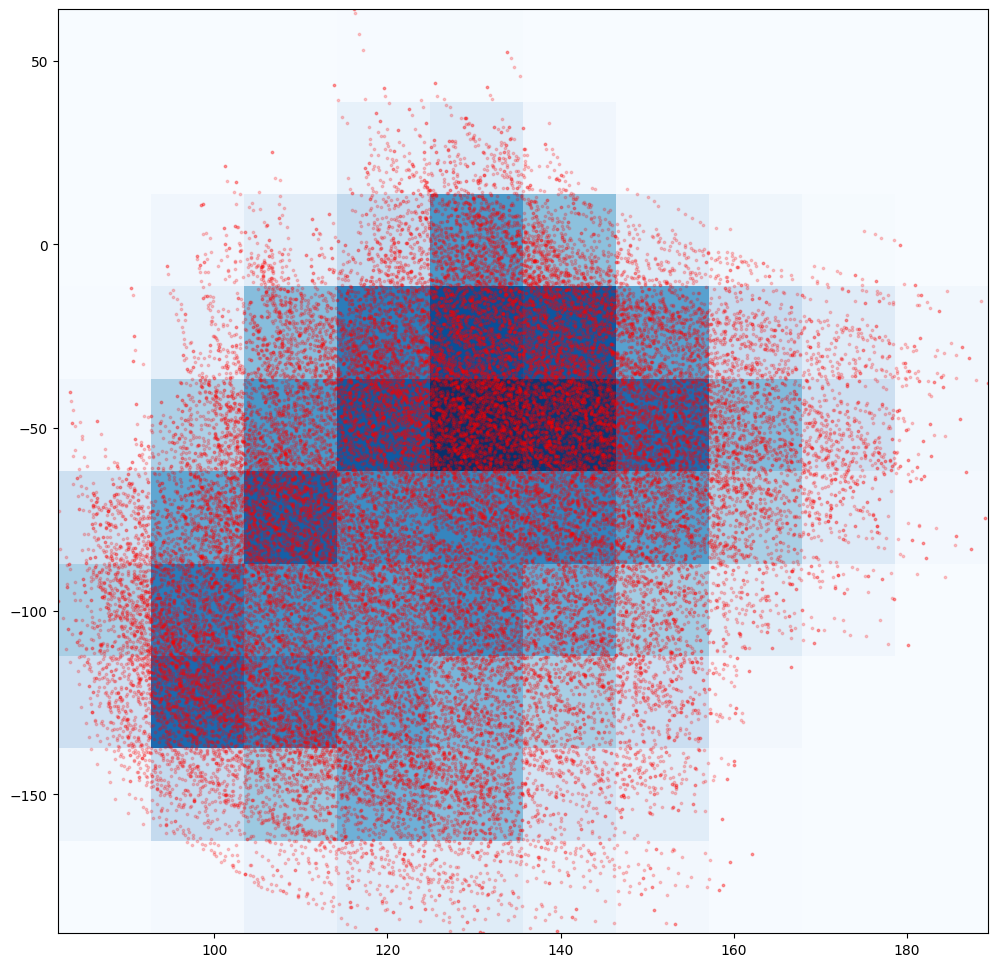

In [73]:
df = df_out[
    df_out["future_id"] < 1000
]

y = df["technical_cost"].to_numpy()
x = df["emission_avg_last_five_years"].to_numpy()

fig, ax = plt.subplots(figsize = (12, 12))

ax.hist2d(x, y, cmap = "Blues")
ax.scatter(x, y, alpha = 0.2, s = 3, color = "red")


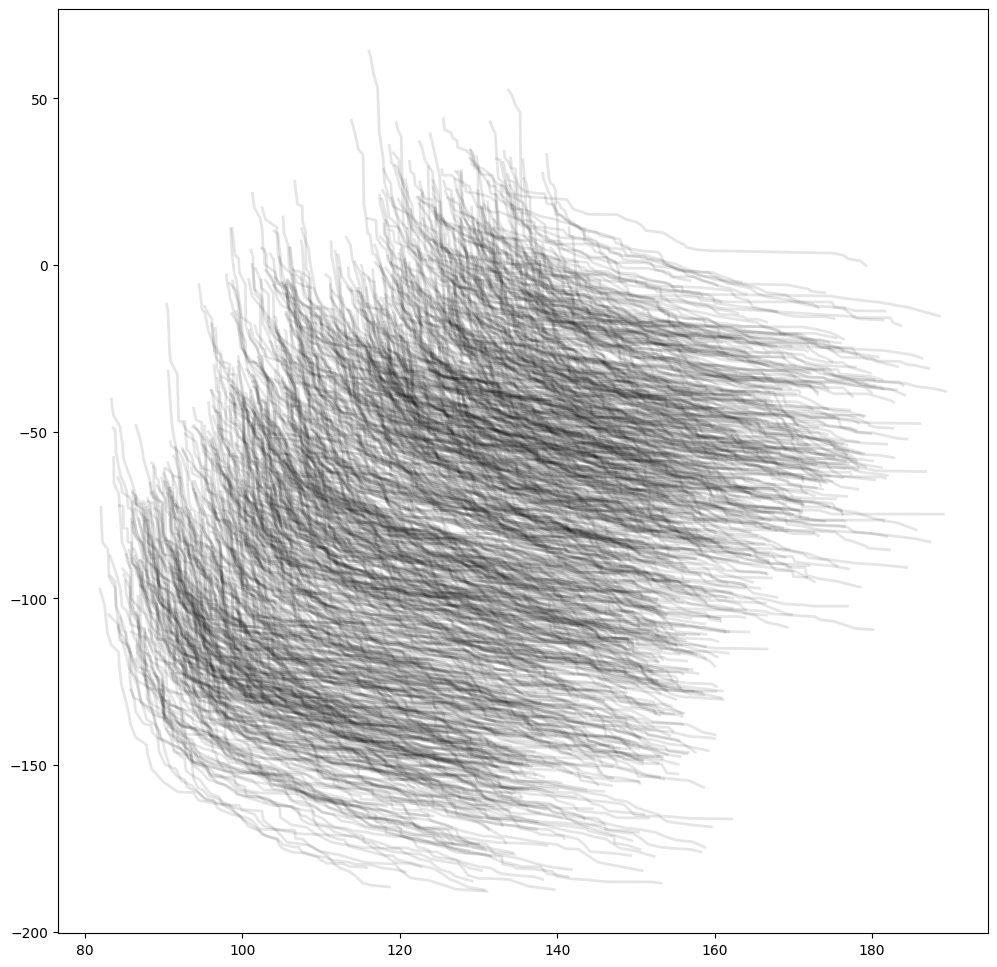

In [86]:
fig, ax = plt.subplots(figsize = (12, 12))
dfg = df_out.groupby(["future_id"])

#ax.hist2d(x, y, cmap = "Blues")
for i, df in dfg:
    df = (
        df
        .sort_values(
            by = ["emission_avg_last_five_years"]
        )
    )
    y = df["technical_cost"].to_numpy()
    x = df["emission_avg_last_five_years"].to_numpy()

    ax.plot(x, y, alpha = 0.1, linewidth = 2, color = "black")




<Axes: xlabel='emission_avg_last_five_years'>

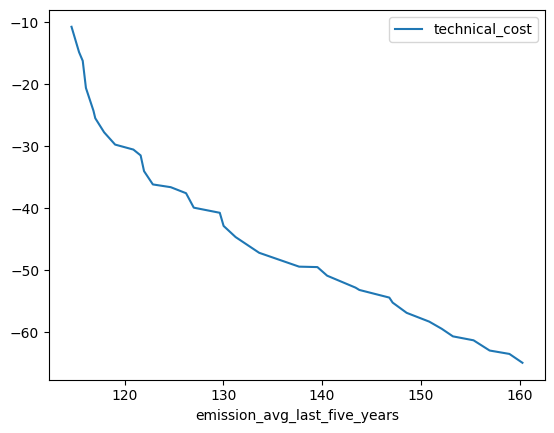

In [84]:
df[["emission_avg_last_five_years", "technical_cost"]].sort_values(by = "emission_avg_last_five_years").plot(x = "emission_avg_last_five_years", y = "technical_cost", )

In [36]:
df_train.to_csv(
    _PATH_PARETOS.joinpath("training_data.csv"),
    encoding = "UTF-8",
    index = None,
)

<function posix.rename(src, dst, *, src_dir_fd=None, dst_dir_fd=None)>

In [307]:
df_pareto_frontiers2 = df_pareto_frontiers.copy()
df_pareto_frontiers2["technical_cost"] += 200



# The field `technical_cost` is `baseline_cost` - `strategy_cost`
- negative values are **HIGHER** investment than baseline, positive values are **LOWEER** investment
- You want to MAXIMIZE the cost to reduce costs, so we MINIMIZE the negative

In [289]:
df_pareto_frontiers["technical_cost"] *= -1

In [284]:
df_train = dict_training_data.get("df")

In [285]:
df_train[["emission_avg_last_five_years", "technical_cost"]].mean(axis = 0)

emission_avg_last_five_years    196.815588
technical_cost                  -28.268133
dtype: float64

<Axes: xlabel='technical_cost', ylabel='emission_avg_last_five_years'>

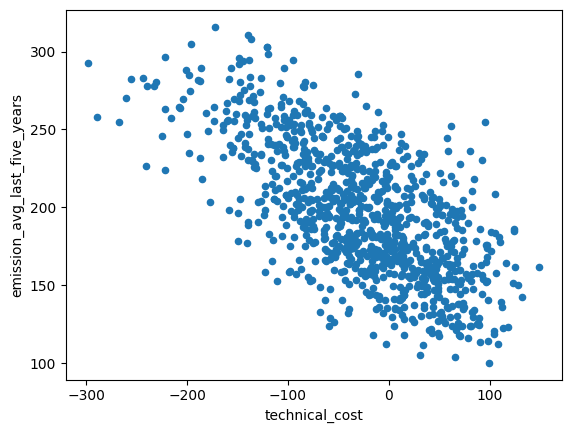

In [286]:
df_train[["emission_avg_last_five_years", "technical_cost"]].plot.scatter(
    x = "technical_cost",
    y = "emission_avg_last_five_years"
)



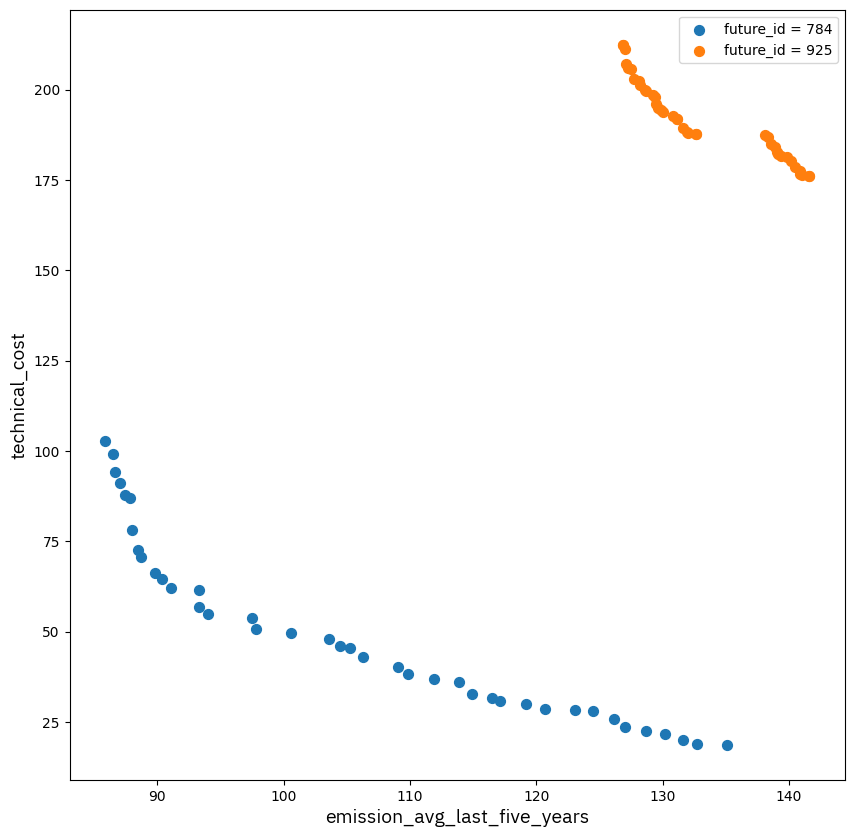

In [309]:
fig, ax = plt.subplots(figsize = (10, 10))

# get labels
labels_y = problem.labels_y
ax.set_xlabel(labels_y[0], fontfamily = "IBM Plex Sans", fontsize = 14, )
ax.set_ylabel(labels_y[1], fontfamily = "IBM Plex Sans", fontsize = 14, )
#.replace("technical_cost", "savings")

dfg = df_pareto_frontiers2.groupby([_FIELD_FUTURE_ID])
for fut, df in dfg:
    
    ax.scatter(
        df[labels_y[0]], 
        df[labels_y[1]], 
        #facecolor = "none",
        #edgecolor = "red",
        label = f"{_FIELD_FUTURE_ID} = {fut[0]}",
        s = 50,
    )

ax.legend()


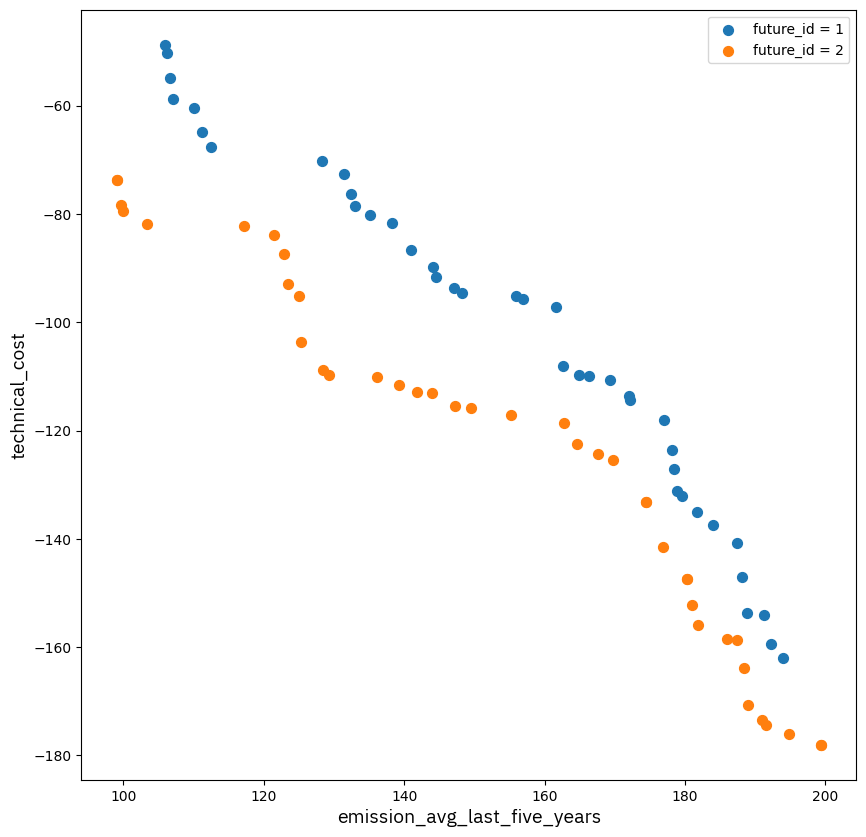

In [271]:
fig, ax = plt.subplots(figsize = (10, 10))

# get labels
labels_y = problem.labels_y
ax.set_xlabel(labels_y[0], fontfamily = "IBM Plex Sans", fontsize = 14, )
ax.set_ylabel(labels_y[1], fontfamily = "IBM Plex Sans", fontsize = 14, )


dfg = df_pareto_frontiers.groupby([_FIELD_FUTURE_ID])
for fut, df in dfg:
    
    ax.scatter(
        df[labels_y[0]], 
        df[labels_y[1]], 
        #facecolor = "none",
        #edgecolor = "red",
        label = f"{_FIELD_FUTURE_ID} = {fut[0]}",
        s = 50,
    )

ax.legend()


# Export

In [193]:
##  SOME BASIC NAMING FUNCTIONS

def get_date(
) -> str:
    """Get date to use as suffix
    """
    now = dt.datetime.now()
    
    year = str(now.year).rjust(4, "0")
    month = str(now.month).rjust(2, "0")
    day = str(now.day).rjust(2, "0")

    out = f"{year}{month}{day}"

    return out



def get_fn_out(
) -> str:
    """Get the name of the file to export
    """
    date = get_date()
    out = f"xgb_pymoo_pareto_front_{date}.csv"
    return out



##  CHECK PATH AND WRITE

path_out = pathlib.Path(os.getcwd()).parents[0].joinpath("optimization", "out")
if not path_out.is_dir():
    path_out.mkdir(exist_ok = True, )

df_pareto_frontiers.to_csv(
    path_out.joinpath(get_fn_out()),
    encoding = "UTF-8",
    index = None,
)




# Validation -- Run against SSP

In [63]:
# add path to sispeuede to sys.path in python
import sys
import warnings
dir_git = "/Users/usuario/git/sisepuede"
if dir_git not in sys.path:
    sys.path.append(dir_git)

warnings.filterwarnings("ignore")

import sisepuede as si
import sisepuede.manager.sisepuede_file_structure as sfs
import sisepuede.transformers as trf
import sisepuede.utilities._toolbox as sf
import sqlalchemy

# hack for now
log_job = None



In [75]:
path_la = pathlib.Path("/Users/usuario/git/sisepuede_region_nbs/louisiana")
path_data = path_la.joinpath("data")
path_inputs = path_data.joinpath("louisiana_inputs_raw.csv")
path_transformations = path_la.joinpath("transformations")
if not path_transformations.exists():
    raise RuntimeError(f"Transformations not found at path '{path_transformations}'")


##  LOAD TRANSFORMATIONS
#
#   - NOTE: the data in df_input are not used; only the templates in strategies
#
df_input = pd.read_csv(path_inputs, )
transformations = trf.Transformations(
    path_transformations,
    df_input = df_input
)
transformers = transformations.transformers

strategies = trf.Strategies(
    transformations,
    export_path = "transformations",
    prebuild = True,
)




###  Get the `SISEPUEDE` object, which we'll use to run across the discovered Pareto frontier

In [76]:
_REGION_NAME = "louisiana"

ssp = si.SISEPUEDE(
    "calibrated",
    db_type = "csv",                          # must run as a CSV for now
    initialize_as_dummy = False,              # no connection to Julia is initialized if set to True
    logger = log_job,
    regions = [_REGION_NAME],
    strategies = strategies,
    try_exogenous_xl_types_in_variable_specification = False,
)

log_job = ssp.logger

2025-11-16 10:43:25,474 - INFO - Successfully initialized SISEPUEDEFileStructure.
2025-11-16 10:43:25,476 - WARNING - Missing key dict_dimensional_keys: key time_series not found. Tables that rely on the time_series will not have index checking.
2025-11-16 10:43:25,476 - INFO - 	Setting export engine to 'csv'.
2025-11-16 10:43:25,476 - WARNING - No index fields defined. Index field values will not be checked when writing to tables.
2025-11-16 10:43:25,477 - INFO - Successfully instantiated table ANALYSIS_METADATA
2025-11-16 10:43:25,477 - WARNING - No index fields found in ATTRIBUTE_DESIGN. Initializing index fields.
2025-11-16 10:43:25,477 - INFO - Successfully instantiated table ATTRIBUTE_DESIGN
2025-11-16 10:43:25,477 - WARNING - No index fields found in ATTRIBUTE_LHC_SAMPLES_EXOGENOUS_UNCERTAINTIES. Initializing index fields.
2025-11-16 10:43:25,478 - INFO - Successfully instantiated table ATTRIBUTE_LHC_SAMPLES_EXOGENOUS_UNCERTAINTIES
2025-11-16 10:43:25,478 - WARNING - No index fi

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


Precompiling NemoMod...
Info Given NemoMod was explicitly requested, output will be shown live 
ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.
   1449.6 ms  ? NemoMod
[ Info: Precompiling NemoMod [a3c327a0-d2f0-11e8-37fd-d12fd35c3c72] 
ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.
┌ Info: Skipping precompilation due to precompilable error. Importing NemoMod [a3c327a0-d2f0-11e8-37fd-d12fd35c3c72].
└   exception = Error when precompiling module, potentially caused by a __precompile__(false) declaration in the module.
2025-11-16 10:44:02,047 - INFO - Successfully initialized JuMP optimizer from solver module HiGHS.
2025-11-16 10:44:02,061 - INFO - Successfully initialized SISEPUEDEModels.
2025-11-16 10:44:02,065 - INFO - Table ANALYSIS_METADATA successfully written to /Users/usuario/git/sisepuede/sisepuede/out/sisepuede_ru

In [95]:

em = ssp.experimental_manager
futures = em.dict_future_trajectories.get(_REGION_NAME)
lhs_design = em.dict_lhs_design.get(_REGION_NAME)


<Axes: xlabel='emission_avg_last_five_years', ylabel='technical_cost'>

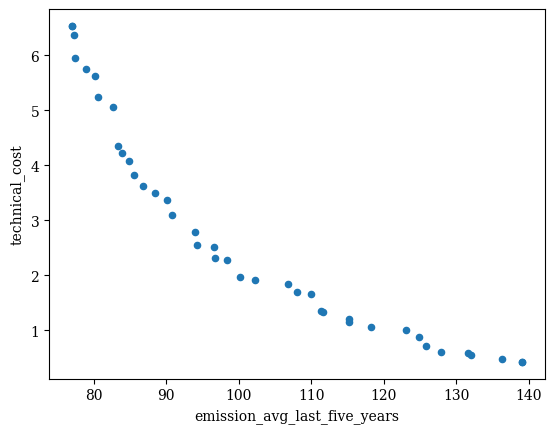

In [522]:
df_frontier22[["emission_avg_last_five_years", "technical_cost"]].plot.scatter(x = "emission_avg_last_five_years", y = "technical_cost")

In [546]:
df_frontier.drop_duplicates(subset = [x for x in df_frontier.columns if x not in ["pareto_index", "future_id"]])

,group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_2_frac_agrc_agriculture_production_lost,group_3_frac_agrc,group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture,group_5_nemomod_entc_frac_min_share_production_fp_hydrogen,group_6_nemomod_en,group_7_,group_8_frac_fgtv_drained_and_waste_ch4_flared_fuel,group_9_efficfactor_enfu_industrial_energy_fuel,group_10_scalar_inen_energy_demand,...,group_54_nemomod_enst_capital_cost_st,group_55_nemomod_entc,group_56_nemomod_entc,group_57_nemomod_entc,group_58_elasticity_trde_mtkm_to_gdp_freight,group_59_elasticity_trde_pkm_to_gdppc,emission_avg_last_five_years,technical_cost,pareto_index,future_id
0,0.903704,0.021616,0.073740,0.280000,0.683730,0.968410,0.790360,0.761769,0.891174,0.701626,...,0.698405,0.403883,0.357435,0.419629,0.323321,0.009536,76.948174,6.535444,0,1
1,0.987953,0.005681,0.054641,0.032535,0.090482,0.460030,0.794099,0.783887,0.826197,0.696008,...,0.698405,0.403883,0.357435,0.419629,0.323321,0.066415,139.113037,0.422475,1,1
2,0.986271,0.005681,0.055081,0.032535,0.090482,0.460030,0.794099,0.783887,0.937766,0.696008,...,0.698405,0.403883,0.357435,0.419629,0.323321,0.066415,139.113037,0.422475,2,1
3,0.903704,0.018552,0.073734,0.279999,0.693544,0.970101,0.790489,0.761769,0.891174,0.701567,...,0.698405,0.403883,0.357435,0.419629,0.323321,0.010357,76.948174,6.535444,3,1
4,0.891592,0.021542,0.130789,0.274165,0.004646,0.996958,0.793025,0.770575,0.827787,0.760097,...,0.698405,0.403883,0.357435,0.419629,0.323321,0.017814,82.710594,5.067284,4,1
5,0.892720,0.023603,0.129407,0.272909,0.693722,0.996880,0.794194,0.766200,0.836275,0.727741,...,0.698405,0.403883,0.357435,0.419629,0.323321,0.015235,90.727348,3.106118,5,1
6,0.905224,0.021630,0.061380,0.041727,0.089168,0.670108,0.793027,0.761431,0.827682,0.695555,...,0.698405,0.403883,0.357435,0.419629,0.323321,0.015497,118.173759,1.051729,6,1
7,0.901772,0.022587,0.068928,0.044912,0.699824,0.993975,0.792954,0.764279,0.888923,0.725854,...,0.698405,0.403883,0.357435,0.419629,0.323321,0.011336,94.016678,2.787442,7,1
8,0.903790,0.021412,0.136838,0.273210,0.686448,0.997505,0.790264,0.783659,0.889688,0.687728,...,0.698405,0.403883,0.357435,0.419629,0.323321,0.060278,83.297867,4.361865,8,1
9,0.988674,0.005782,0.134905,0.033364,0.060908,0.455000,0.790577,0.761081,0.827698,0.701057,...,0.698405,0.403883,0.357435,0.419629,0.323321,0.013945,136.302155,0.481109,9,1


In [527]:
path_frontier = pathlib.Path("/Users/usuario/git/ssp_louisiana/metamodel/data/iterative_paretos_20251119/frontier_1.csv")
df_frontier = pd.read_csv(path_frontier)




# now, have to build the futures
def build_future_perturbation_vector(
    df_frontier: pd.DataFrame,
    lhs_design: 'LHSDesign',
) -> pd.Series:
    """
    """

    ##  RENAME INPUT DATA TO MATCH GROUPS
    
    regex = re.compile("^group_(\d*)")
    
    dict_rnm = {}
    for x in df_frontier.columns:
        match = regex.match(x)
        if match is None: continue
    
        new = int(match.groups()[0])
        dict_rnm.update({x: new})
    
    df_new = (
        df_frontier
        .rename(columns = dict_rnm, )
        .copy()
    )


    ##  THEN, SPLIT OUT

    #
    fields_split = [
        lhs_design.fields_factors_l,
        lhs_design.fields_factors_x
    ]

    dfs = []

    for fields in fields_split:
        
        fields_ext = [x for x in df_new.columns if x in fields]
        df = df_new[fields_ext]

        # add -1 for baseline value if they're not in here
        for x in fields:
            if x not in df.columns:
                df[x] = -1

        dfs.append(df)
            
    # finally, sort them
    df_l = dfs[0][lhs_design.fields_factors_l]
    df_x = dfs[1][lhs_design.fields_factors_x]


    out = (df_l, df_x, )

    return out






df_l, df_x = build_future_perturbation_vector(df_frontier, lhs_design, )

dfs_in = []
dfs_out = []
strat_id = 6004

for i, series_l in df_l.iterrows():
    
    series_x = df_x.iloc[i]
    series_frontier = df_frontier.iloc[i]

    primary_index = int(series_frontier.get(_FIELD_PARETO_INDEX, ))
    
    #if i > 1: continue

    df_in = futures.generate_future_from_lhs_vector(
        series_x,
        series_l,
        future_id = primary_index,
    )

    df_in = (
        df_in[
            df_in[ssp.key_strategy].isin([strat_id], )
        ]
        .reset_index(drop = True, )
        .drop(columns = [ssp.key_future, ssp.key_strategy])
    )

    df_in[_FIELD_PARETO_INDEX] = primary_index
    dfs_in.append(df_in, )

    df_out = ssp.models(
        df_in, 
        include_electricity_in_energy = True, 
        time_periods_base = list(range(12)),
    )
    df_out[_FIELD_PARETO_INDEX] = primary_index
    dfs_out.append(df_out, )
    

dfs_out = sf._concat_df(dfs_out)
dfs_in = sf._concat_df(dfs_in)


2025-11-18 12:59:06,196 - INFO - Running AFOLU model
2025-11-18 12:59:06,453 - INFO - AFOLU model run successfully completed
2025-11-18 12:59:06,453 - INFO - Running CircularEconomy model
2025-11-18 12:59:06,480 - INFO - CircularEconomy model run successfully completed
2025-11-18 12:59:06,480 - INFO - Running IPPU model
2025-11-18 12:59:06,521 - INFO - IPPU model run successfully completed
2025-11-18 12:59:06,521 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2025-11-18 12:59:06,532 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2025-11-18 12:59:06,584 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2025-11-18 12:59:06,585 - INFO - Running Energy model (Electricity and Fuel Production: trying to call Julia)
2025-11-18 13:00:30,991 - INFO - NemoMod ran successfully with the following status: OPTIMAL
2025-11-18 13:00:30,998 - INFO - En

set ['emission_co2e_co2_entc_bmass_processing_and_refinement_fp_hydrogen_gasification'] = 0 in energy production. FIX WITH NEW fp_hydrogen_gasification_biomass TECH.


2025-11-18 13:00:32,014 - INFO - Running AFOLU model
2025-11-18 13:00:32,264 - INFO - AFOLU model run successfully completed
2025-11-18 13:00:32,265 - INFO - Running CircularEconomy model
2025-11-18 13:00:32,289 - INFO - CircularEconomy model run successfully completed
2025-11-18 13:00:32,289 - INFO - Running IPPU model
2025-11-18 13:00:32,329 - INFO - IPPU model run successfully completed
2025-11-18 13:00:32,329 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2025-11-18 13:00:32,339 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2025-11-18 13:00:32,387 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2025-11-18 13:00:32,387 - INFO - Running Energy model (Electricity and Fuel Production: trying to call Julia)
2025-11-18 13:01:46,212 - INFO - NemoMod ran successfully with the following status: OPTIMAL
2025-11-18 13:01:46,223 - INFO - En

set ['emission_co2e_co2_entc_bmass_processing_and_refinement_fp_hydrogen_gasification'] = 0 in energy production. FIX WITH NEW fp_hydrogen_gasification_biomass TECH.


2025-11-18 13:01:47,353 - INFO - Running AFOLU model
2025-11-18 13:01:47,622 - INFO - AFOLU model run successfully completed
2025-11-18 13:01:47,622 - INFO - Running CircularEconomy model
2025-11-18 13:01:47,650 - INFO - CircularEconomy model run successfully completed
2025-11-18 13:01:47,650 - INFO - Running IPPU model
2025-11-18 13:01:47,694 - INFO - IPPU model run successfully completed
2025-11-18 13:01:47,695 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2025-11-18 13:01:47,705 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2025-11-18 13:01:47,756 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2025-11-18 13:01:47,757 - INFO - Running Energy model (Electricity and Fuel Production: trying to call Julia)
2025-11-18 13:18:37,531 - INFO - NemoMod ran successfully with the following status: TIME_LIMIT
2025-11-18 13:18:37,539 - INFO -

set ['emission_co2e_co2_entc_bmass_processing_and_refinement_fp_hydrogen_gasification'] = 0 in energy production. FIX WITH NEW fp_hydrogen_gasification_biomass TECH.


2025-11-18 13:18:38,505 - INFO - Running AFOLU model
2025-11-18 13:18:38,751 - INFO - AFOLU model run successfully completed
2025-11-18 13:18:38,751 - INFO - Running CircularEconomy model
2025-11-18 13:18:38,775 - INFO - CircularEconomy model run successfully completed
2025-11-18 13:18:38,776 - INFO - Running IPPU model
2025-11-18 13:18:38,813 - INFO - IPPU model run successfully completed
2025-11-18 13:18:38,813 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2025-11-18 13:18:38,824 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2025-11-18 13:18:38,869 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2025-11-18 13:18:38,869 - INFO - Running Energy model (Electricity and Fuel Production: trying to call Julia)
2025-11-18 13:43:38,076 - INFO - NemoMod ran successfully with the following status: OPTIMAL
2025-11-18 13:43:38,099 - INFO - En

set ['emission_co2e_co2_entc_bmass_processing_and_refinement_fp_hydrogen_gasification'] = 0 in energy production. FIX WITH NEW fp_hydrogen_gasification_biomass TECH.


2025-11-18 13:43:39,188 - INFO - Running AFOLU model
2025-11-18 13:43:39,441 - INFO - AFOLU model run successfully completed
2025-11-18 13:43:39,441 - INFO - Running CircularEconomy model
2025-11-18 13:43:39,465 - INFO - CircularEconomy model run successfully completed
2025-11-18 13:43:39,466 - INFO - Running IPPU model
2025-11-18 13:43:39,505 - INFO - IPPU model run successfully completed
2025-11-18 13:43:39,505 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2025-11-18 13:43:39,516 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2025-11-18 13:43:39,566 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2025-11-18 13:43:39,566 - INFO - Running Energy model (Electricity and Fuel Production: trying to call Julia)
2025-11-18 13:44:41,436 - INFO - NemoMod ran successfully with the following status: OPTIMAL
2025-11-18 13:44:41,443 - INFO - En

set ['emission_co2e_co2_entc_bmass_processing_and_refinement_fp_hydrogen_gasification'] = 0 in energy production. FIX WITH NEW fp_hydrogen_gasification_biomass TECH.


2025-11-18 13:44:42,404 - INFO - Running AFOLU model
2025-11-18 13:44:42,659 - INFO - AFOLU model run successfully completed
2025-11-18 13:44:42,660 - INFO - Running CircularEconomy model
2025-11-18 13:44:42,684 - INFO - CircularEconomy model run successfully completed
2025-11-18 13:44:42,685 - INFO - Running IPPU model
2025-11-18 13:44:42,724 - INFO - IPPU model run successfully completed
2025-11-18 13:44:42,725 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2025-11-18 13:44:42,736 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2025-11-18 13:44:42,784 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2025-11-18 13:44:42,785 - INFO - Running Energy model (Electricity and Fuel Production: trying to call Julia)
2025-11-18 13:58:40,775 - INFO - NemoMod ran successfully with the following status: OPTIMAL
2025-11-18 13:58:40,789 - INFO - En

set ['emission_co2e_co2_entc_bmass_processing_and_refinement_fp_hydrogen_gasification'] = 0 in energy production. FIX WITH NEW fp_hydrogen_gasification_biomass TECH.


2025-11-18 13:58:42,045 - INFO - Running AFOLU model
2025-11-18 13:58:42,325 - INFO - AFOLU model run successfully completed
2025-11-18 13:58:42,325 - INFO - Running CircularEconomy model
2025-11-18 13:58:42,351 - INFO - CircularEconomy model run successfully completed
2025-11-18 13:58:42,351 - INFO - Running IPPU model
2025-11-18 13:58:42,398 - INFO - IPPU model run successfully completed
2025-11-18 13:58:42,399 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2025-11-18 13:58:42,411 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2025-11-18 13:58:42,462 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2025-11-18 13:58:42,463 - INFO - Running Energy model (Electricity and Fuel Production: trying to call Julia)
2025-11-18 14:14:26,469 - INFO - NemoMod ran successfully with the following status: TIME_LIMIT
2025-11-18 14:14:26,475 - INFO -

set ['emission_co2e_co2_entc_bmass_processing_and_refinement_fp_hydrogen_gasification'] = 0 in energy production. FIX WITH NEW fp_hydrogen_gasification_biomass TECH.


2025-11-18 14:14:27,481 - INFO - Running AFOLU model
2025-11-18 14:14:27,727 - INFO - AFOLU model run successfully completed
2025-11-18 14:14:27,728 - INFO - Running CircularEconomy model
2025-11-18 14:14:27,751 - INFO - CircularEconomy model run successfully completed
2025-11-18 14:14:27,752 - INFO - Running IPPU model
2025-11-18 14:14:27,788 - INFO - IPPU model run successfully completed
2025-11-18 14:14:27,788 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2025-11-18 14:14:27,798 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2025-11-18 14:14:27,842 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2025-11-18 14:14:27,843 - INFO - Running Energy model (Electricity and Fuel Production: trying to call Julia)
2025-11-18 14:18:05,164 - INFO - NemoMod ran successfully with the following status: OPTIMAL
2025-11-18 14:18:05,177 - INFO - En

set ['emission_co2e_co2_entc_bmass_processing_and_refinement_fp_hydrogen_gasification'] = 0 in energy production. FIX WITH NEW fp_hydrogen_gasification_biomass TECH.


2025-11-18 14:18:06,250 - INFO - Running AFOLU model
2025-11-18 14:18:06,510 - INFO - AFOLU model run successfully completed
2025-11-18 14:18:06,510 - INFO - Running CircularEconomy model
2025-11-18 14:18:06,533 - INFO - CircularEconomy model run successfully completed
2025-11-18 14:18:06,534 - INFO - Running IPPU model
2025-11-18 14:18:06,573 - INFO - IPPU model run successfully completed
2025-11-18 14:18:06,574 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2025-11-18 14:18:06,583 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2025-11-18 14:18:06,630 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2025-11-18 14:18:06,630 - INFO - Running Energy model (Electricity and Fuel Production: trying to call Julia)
2025-11-18 14:19:28,791 - INFO - NemoMod ran successfully with the following status: OPTIMAL
2025-11-18 14:19:28,797 - INFO - En

set ['emission_co2e_co2_entc_bmass_processing_and_refinement_fp_hydrogen_gasification'] = 0 in energy production. FIX WITH NEW fp_hydrogen_gasification_biomass TECH.


2025-11-18 14:19:29,806 - INFO - Running AFOLU model
2025-11-18 14:19:30,060 - INFO - AFOLU model run successfully completed
2025-11-18 14:19:30,060 - INFO - Running CircularEconomy model
2025-11-18 14:19:30,084 - INFO - CircularEconomy model run successfully completed
2025-11-18 14:19:30,084 - INFO - Running IPPU model
2025-11-18 14:19:30,124 - INFO - IPPU model run successfully completed
2025-11-18 14:19:30,124 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2025-11-18 14:19:30,135 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2025-11-18 14:19:30,182 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2025-11-18 14:19:30,183 - INFO - Running Energy model (Electricity and Fuel Production: trying to call Julia)
2025-11-18 14:37:26,463 - INFO - NemoMod ran successfully with the following status: TIME_LIMIT
2025-11-18 14:37:26,470 - INFO -

set ['emission_co2e_co2_entc_bmass_processing_and_refinement_fp_hydrogen_gasification'] = 0 in energy production. FIX WITH NEW fp_hydrogen_gasification_biomass TECH.


2025-11-18 14:37:27,514 - INFO - Running AFOLU model
2025-11-18 14:37:27,760 - INFO - AFOLU model run successfully completed
2025-11-18 14:37:27,760 - INFO - Running CircularEconomy model
2025-11-18 14:37:27,784 - INFO - CircularEconomy model run successfully completed
2025-11-18 14:37:27,784 - INFO - Running IPPU model
2025-11-18 14:37:27,824 - INFO - IPPU model run successfully completed
2025-11-18 14:37:27,825 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2025-11-18 14:37:27,835 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2025-11-18 14:37:27,883 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2025-11-18 14:37:27,884 - INFO - Running Energy model (Electricity and Fuel Production: trying to call Julia)
2025-11-18 14:39:31,473 - INFO - NemoMod ran successfully with the following status: OPTIMAL
2025-11-18 14:39:31,481 - INFO - En

set ['emission_co2e_co2_entc_bmass_processing_and_refinement_fp_hydrogen_gasification'] = 0 in energy production. FIX WITH NEW fp_hydrogen_gasification_biomass TECH.


2025-11-18 14:39:32,497 - INFO - Running AFOLU model
2025-11-18 14:39:32,742 - INFO - AFOLU model run successfully completed
2025-11-18 14:39:32,743 - INFO - Running CircularEconomy model
2025-11-18 14:39:32,766 - INFO - CircularEconomy model run successfully completed
2025-11-18 14:39:32,767 - INFO - Running IPPU model
2025-11-18 14:39:32,805 - INFO - IPPU model run successfully completed
2025-11-18 14:39:32,806 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2025-11-18 14:39:32,815 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2025-11-18 14:39:32,861 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2025-11-18 14:39:32,862 - INFO - Running Energy model (Electricity and Fuel Production: trying to call Julia)
2025-11-18 14:40:35,739 - INFO - NemoMod ran successfully with the following status: OPTIMAL
2025-11-18 14:40:35,747 - INFO - En

set ['emission_co2e_co2_entc_bmass_processing_and_refinement_fp_hydrogen_gasification'] = 0 in energy production. FIX WITH NEW fp_hydrogen_gasification_biomass TECH.


2025-11-18 14:40:36,850 - INFO - Running AFOLU model
2025-11-18 14:40:37,121 - INFO - AFOLU model run successfully completed
2025-11-18 14:40:37,121 - INFO - Running CircularEconomy model
2025-11-18 14:40:37,148 - INFO - CircularEconomy model run successfully completed
2025-11-18 14:40:37,149 - INFO - Running IPPU model
2025-11-18 14:40:37,192 - INFO - IPPU model run successfully completed
2025-11-18 14:40:37,192 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2025-11-18 14:40:37,203 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2025-11-18 14:40:37,257 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2025-11-18 14:40:37,257 - INFO - Running Energy model (Electricity and Fuel Production: trying to call Julia)
2025-11-18 14:41:20,510 - INFO - NemoMod ran successfully with the following status: OPTIMAL
2025-11-18 14:41:20,518 - INFO - En

set ['emission_co2e_co2_entc_bmass_processing_and_refinement_fp_hydrogen_gasification'] = 0 in energy production. FIX WITH NEW fp_hydrogen_gasification_biomass TECH.


2025-11-18 14:41:21,536 - INFO - Running AFOLU model
2025-11-18 14:41:21,809 - INFO - AFOLU model run successfully completed
2025-11-18 14:41:21,810 - INFO - Running CircularEconomy model
2025-11-18 14:41:21,835 - INFO - CircularEconomy model run successfully completed
2025-11-18 14:41:21,835 - INFO - Running IPPU model
2025-11-18 14:41:21,874 - INFO - IPPU model run successfully completed
2025-11-18 14:41:21,874 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2025-11-18 14:41:21,885 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2025-11-18 14:41:21,934 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2025-11-18 14:41:21,934 - INFO - Running Energy model (Electricity and Fuel Production: trying to call Julia)
2025-11-18 14:42:34,120 - INFO - NemoMod ran successfully with the following status: OPTIMAL
2025-11-18 14:42:34,127 - INFO - En

set ['emission_co2e_co2_entc_bmass_processing_and_refinement_fp_hydrogen_gasification'] = 0 in energy production. FIX WITH NEW fp_hydrogen_gasification_biomass TECH.


2025-11-18 14:42:35,137 - INFO - Running AFOLU model
2025-11-18 14:42:35,395 - INFO - AFOLU model run successfully completed
2025-11-18 14:42:35,396 - INFO - Running CircularEconomy model
2025-11-18 14:42:35,419 - INFO - CircularEconomy model run successfully completed
2025-11-18 14:42:35,420 - INFO - Running IPPU model
2025-11-18 14:42:35,459 - INFO - IPPU model run successfully completed
2025-11-18 14:42:35,460 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2025-11-18 14:42:35,469 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2025-11-18 14:42:35,518 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2025-11-18 14:42:35,518 - INFO - Running Energy model (Electricity and Fuel Production: trying to call Julia)
2025-11-18 14:46:12,200 - INFO - NemoMod ran successfully with the following status: OPTIMAL
2025-11-18 14:46:12,211 - INFO - En

set ['emission_co2e_co2_entc_bmass_processing_and_refinement_fp_hydrogen_gasification'] = 0 in energy production. FIX WITH NEW fp_hydrogen_gasification_biomass TECH.


2025-11-18 14:46:13,353 - INFO - Running AFOLU model
2025-11-18 14:46:13,630 - INFO - AFOLU model run successfully completed
2025-11-18 14:46:13,631 - INFO - Running CircularEconomy model
2025-11-18 14:46:13,656 - INFO - CircularEconomy model run successfully completed
2025-11-18 14:46:13,656 - INFO - Running IPPU model
2025-11-18 14:46:13,695 - INFO - IPPU model run successfully completed
2025-11-18 14:46:13,695 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2025-11-18 14:46:13,705 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2025-11-18 14:46:13,755 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2025-11-18 14:46:13,756 - INFO - Running Energy model (Electricity and Fuel Production: trying to call Julia)
2025-11-18 14:47:28,991 - INFO - NemoMod ran successfully with the following status: OPTIMAL
2025-11-18 14:47:28,999 - INFO - En

set ['emission_co2e_co2_entc_bmass_processing_and_refinement_fp_hydrogen_gasification'] = 0 in energy production. FIX WITH NEW fp_hydrogen_gasification_biomass TECH.


2025-11-18 14:47:30,140 - INFO - Running AFOLU model
2025-11-18 14:47:30,411 - INFO - AFOLU model run successfully completed
2025-11-18 14:47:30,411 - INFO - Running CircularEconomy model
2025-11-18 14:47:30,436 - INFO - CircularEconomy model run successfully completed
2025-11-18 14:47:30,437 - INFO - Running IPPU model
2025-11-18 14:47:30,476 - INFO - IPPU model run successfully completed
2025-11-18 14:47:30,477 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2025-11-18 14:47:30,487 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2025-11-18 14:47:30,537 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2025-11-18 14:47:30,538 - INFO - Running Energy model (Electricity and Fuel Production: trying to call Julia)
2025-11-18 14:48:58,880 - INFO - NemoMod ran successfully with the following status: OPTIMAL
2025-11-18 14:48:58,894 - INFO - En

set ['emission_co2e_co2_entc_bmass_processing_and_refinement_fp_hydrogen_gasification'] = 0 in energy production. FIX WITH NEW fp_hydrogen_gasification_biomass TECH.


2025-11-18 14:49:00,072 - INFO - Running AFOLU model
2025-11-18 14:49:00,343 - INFO - AFOLU model run successfully completed
2025-11-18 14:49:00,344 - INFO - Running CircularEconomy model
2025-11-18 14:49:00,371 - INFO - CircularEconomy model run successfully completed
2025-11-18 14:49:00,371 - INFO - Running IPPU model
2025-11-18 14:49:00,415 - INFO - IPPU model run successfully completed
2025-11-18 14:49:00,415 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2025-11-18 14:49:00,427 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2025-11-18 14:49:00,478 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2025-11-18 14:49:00,478 - INFO - Running Energy model (Electricity and Fuel Production: trying to call Julia)
2025-11-18 14:50:12,316 - INFO - NemoMod ran successfully with the following status: OPTIMAL
2025-11-18 14:50:12,328 - INFO - En

set ['emission_co2e_co2_entc_bmass_processing_and_refinement_fp_hydrogen_gasification'] = 0 in energy production. FIX WITH NEW fp_hydrogen_gasification_biomass TECH.


2025-11-18 14:50:13,449 - INFO - Running AFOLU model
2025-11-18 14:50:13,717 - INFO - AFOLU model run successfully completed
2025-11-18 14:50:13,717 - INFO - Running CircularEconomy model
2025-11-18 14:50:13,742 - INFO - CircularEconomy model run successfully completed
2025-11-18 14:50:13,743 - INFO - Running IPPU model
2025-11-18 14:50:13,782 - INFO - IPPU model run successfully completed
2025-11-18 14:50:13,783 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2025-11-18 14:50:13,793 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2025-11-18 14:50:13,846 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2025-11-18 14:50:13,847 - INFO - Running Energy model (Electricity and Fuel Production: trying to call Julia)
2025-11-18 14:51:06,082 - INFO - NemoMod ran successfully with the following status: OPTIMAL
2025-11-18 14:51:06,089 - INFO - En

set ['emission_co2e_co2_entc_bmass_processing_and_refinement_fp_hydrogen_gasification'] = 0 in energy production. FIX WITH NEW fp_hydrogen_gasification_biomass TECH.


2025-11-18 14:51:07,120 - INFO - Running AFOLU model
2025-11-18 14:51:07,377 - INFO - AFOLU model run successfully completed
2025-11-18 14:51:07,378 - INFO - Running CircularEconomy model
2025-11-18 14:51:07,403 - INFO - CircularEconomy model run successfully completed
2025-11-18 14:51:07,404 - INFO - Running IPPU model
2025-11-18 14:51:07,444 - INFO - IPPU model run successfully completed
2025-11-18 14:51:07,444 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2025-11-18 14:51:07,455 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2025-11-18 14:51:07,503 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2025-11-18 14:51:07,503 - INFO - Running Energy model (Electricity and Fuel Production: trying to call Julia)
2025-11-18 14:52:41,636 - INFO - NemoMod ran successfully with the following status: OPTIMAL
2025-11-18 14:52:41,647 - INFO - En

set ['emission_co2e_co2_entc_bmass_processing_and_refinement_fp_hydrogen_gasification'] = 0 in energy production. FIX WITH NEW fp_hydrogen_gasification_biomass TECH.


2025-11-18 14:52:42,747 - INFO - Running AFOLU model
2025-11-18 14:52:43,012 - INFO - AFOLU model run successfully completed
2025-11-18 14:52:43,013 - INFO - Running CircularEconomy model
2025-11-18 14:52:43,037 - INFO - CircularEconomy model run successfully completed
2025-11-18 14:52:43,037 - INFO - Running IPPU model
2025-11-18 14:52:43,077 - INFO - IPPU model run successfully completed
2025-11-18 14:52:43,078 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2025-11-18 14:52:43,088 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2025-11-18 14:52:43,136 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2025-11-18 14:52:43,136 - INFO - Running Energy model (Electricity and Fuel Production: trying to call Julia)
2025-11-18 14:53:42,729 - INFO - NemoMod ran successfully with the following status: OPTIMAL
2025-11-18 14:53:42,737 - INFO - En

set ['emission_co2e_co2_entc_bmass_processing_and_refinement_fp_hydrogen_gasification'] = 0 in energy production. FIX WITH NEW fp_hydrogen_gasification_biomass TECH.


2025-11-18 14:53:43,810 - INFO - Running AFOLU model
2025-11-18 14:53:44,085 - INFO - AFOLU model run successfully completed
2025-11-18 14:53:44,085 - INFO - Running CircularEconomy model
2025-11-18 14:53:44,110 - INFO - CircularEconomy model run successfully completed
2025-11-18 14:53:44,111 - INFO - Running IPPU model
2025-11-18 14:53:44,151 - INFO - IPPU model run successfully completed
2025-11-18 14:53:44,151 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2025-11-18 14:53:44,161 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2025-11-18 14:53:44,209 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2025-11-18 14:53:44,209 - INFO - Running Energy model (Electricity and Fuel Production: trying to call Julia)
2025-11-18 14:55:41,842 - INFO - NemoMod ran successfully with the following status: OPTIMAL
2025-11-18 14:55:41,864 - INFO - En

set ['emission_co2e_co2_entc_bmass_processing_and_refinement_fp_hydrogen_gasification'] = 0 in energy production. FIX WITH NEW fp_hydrogen_gasification_biomass TECH.


2025-11-18 14:55:43,188 - INFO - Running AFOLU model
2025-11-18 14:55:43,466 - INFO - AFOLU model run successfully completed
2025-11-18 14:55:43,466 - INFO - Running CircularEconomy model
2025-11-18 14:55:43,495 - INFO - CircularEconomy model run successfully completed
2025-11-18 14:55:43,496 - INFO - Running IPPU model
2025-11-18 14:55:43,541 - INFO - IPPU model run successfully completed
2025-11-18 14:55:43,542 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2025-11-18 14:55:43,552 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2025-11-18 14:55:43,607 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2025-11-18 14:55:43,607 - INFO - Running Energy model (Electricity and Fuel Production: trying to call Julia)
2025-11-18 14:57:43,928 - INFO - NemoMod ran successfully with the following status: OPTIMAL
2025-11-18 14:57:43,940 - INFO - En

set ['emission_co2e_co2_entc_bmass_processing_and_refinement_fp_hydrogen_gasification'] = 0 in energy production. FIX WITH NEW fp_hydrogen_gasification_biomass TECH.


2025-11-18 14:57:45,086 - INFO - Running AFOLU model
2025-11-18 14:57:45,349 - INFO - AFOLU model run successfully completed
2025-11-18 14:57:45,350 - INFO - Running CircularEconomy model
2025-11-18 14:57:45,375 - INFO - CircularEconomy model run successfully completed
2025-11-18 14:57:45,375 - INFO - Running IPPU model
2025-11-18 14:57:45,416 - INFO - IPPU model run successfully completed
2025-11-18 14:57:45,416 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2025-11-18 14:57:45,427 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2025-11-18 14:57:45,476 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2025-11-18 14:57:45,476 - INFO - Running Energy model (Electricity and Fuel Production: trying to call Julia)
2025-11-18 14:59:17,734 - INFO - NemoMod ran successfully with the following status: OPTIMAL
2025-11-18 14:59:17,742 - INFO - En

set ['emission_co2e_co2_entc_bmass_processing_and_refinement_fp_hydrogen_gasification'] = 0 in energy production. FIX WITH NEW fp_hydrogen_gasification_biomass TECH.


2025-11-18 14:59:18,800 - INFO - Running AFOLU model
2025-11-18 14:59:19,058 - INFO - AFOLU model run successfully completed
2025-11-18 14:59:19,058 - INFO - Running CircularEconomy model
2025-11-18 14:59:19,083 - INFO - CircularEconomy model run successfully completed
2025-11-18 14:59:19,083 - INFO - Running IPPU model
2025-11-18 14:59:19,123 - INFO - IPPU model run successfully completed
2025-11-18 14:59:19,123 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2025-11-18 14:59:19,134 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2025-11-18 14:59:19,181 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2025-11-18 14:59:19,182 - INFO - Running Energy model (Electricity and Fuel Production: trying to call Julia)
2025-11-18 15:00:57,568 - INFO - NemoMod ran successfully with the following status: OPTIMAL
2025-11-18 15:00:57,578 - INFO - En

set ['emission_co2e_co2_entc_bmass_processing_and_refinement_fp_hydrogen_gasification'] = 0 in energy production. FIX WITH NEW fp_hydrogen_gasification_biomass TECH.


2025-11-18 15:00:58,688 - INFO - Running AFOLU model
2025-11-18 15:00:58,952 - INFO - AFOLU model run successfully completed
2025-11-18 15:00:58,953 - INFO - Running CircularEconomy model
2025-11-18 15:00:58,977 - INFO - CircularEconomy model run successfully completed
2025-11-18 15:00:58,978 - INFO - Running IPPU model
2025-11-18 15:00:59,018 - INFO - IPPU model run successfully completed
2025-11-18 15:00:59,019 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2025-11-18 15:00:59,029 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2025-11-18 15:00:59,077 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2025-11-18 15:00:59,078 - INFO - Running Energy model (Electricity and Fuel Production: trying to call Julia)
2025-11-18 15:02:00,451 - INFO - NemoMod ran successfully with the following status: OPTIMAL
2025-11-18 15:02:00,458 - INFO - En

set ['emission_co2e_co2_entc_bmass_processing_and_refinement_fp_hydrogen_gasification'] = 0 in energy production. FIX WITH NEW fp_hydrogen_gasification_biomass TECH.


2025-11-18 15:02:01,494 - INFO - Running AFOLU model
2025-11-18 15:02:01,772 - INFO - AFOLU model run successfully completed
2025-11-18 15:02:01,773 - INFO - Running CircularEconomy model
2025-11-18 15:02:01,798 - INFO - CircularEconomy model run successfully completed
2025-11-18 15:02:01,798 - INFO - Running IPPU model
2025-11-18 15:02:01,839 - INFO - IPPU model run successfully completed
2025-11-18 15:02:01,839 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2025-11-18 15:02:01,850 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2025-11-18 15:02:01,899 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2025-11-18 15:02:01,900 - INFO - Running Energy model (Electricity and Fuel Production: trying to call Julia)
2025-11-18 15:02:44,099 - INFO - NemoMod ran successfully with the following status: OPTIMAL
2025-11-18 15:02:44,107 - INFO - En

set ['emission_co2e_co2_entc_bmass_processing_and_refinement_fp_hydrogen_gasification'] = 0 in energy production. FIX WITH NEW fp_hydrogen_gasification_biomass TECH.


2025-11-18 15:02:45,133 - INFO - Running AFOLU model
2025-11-18 15:02:45,389 - INFO - AFOLU model run successfully completed
2025-11-18 15:02:45,389 - INFO - Running CircularEconomy model
2025-11-18 15:02:45,413 - INFO - CircularEconomy model run successfully completed
2025-11-18 15:02:45,414 - INFO - Running IPPU model
2025-11-18 15:02:45,452 - INFO - IPPU model run successfully completed
2025-11-18 15:02:45,453 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2025-11-18 15:02:45,463 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2025-11-18 15:02:45,510 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2025-11-18 15:02:45,510 - INFO - Running Energy model (Electricity and Fuel Production: trying to call Julia)
2025-11-18 15:04:04,700 - INFO - NemoMod ran successfully with the following status: OPTIMAL
2025-11-18 15:04:04,707 - INFO - En

set ['emission_co2e_co2_entc_bmass_processing_and_refinement_fp_hydrogen_gasification'] = 0 in energy production. FIX WITH NEW fp_hydrogen_gasification_biomass TECH.


2025-11-18 15:04:05,716 - INFO - Running AFOLU model
2025-11-18 15:04:06,001 - INFO - AFOLU model run successfully completed
2025-11-18 15:04:06,002 - INFO - Running CircularEconomy model
2025-11-18 15:04:06,027 - INFO - CircularEconomy model run successfully completed
2025-11-18 15:04:06,027 - INFO - Running IPPU model
2025-11-18 15:04:06,069 - INFO - IPPU model run successfully completed
2025-11-18 15:04:06,070 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2025-11-18 15:04:06,080 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2025-11-18 15:04:06,128 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2025-11-18 15:04:06,128 - INFO - Running Energy model (Electricity and Fuel Production: trying to call Julia)
2025-11-18 15:04:56,007 - INFO - NemoMod ran successfully with the following status: OPTIMAL
2025-11-18 15:04:56,016 - INFO - En

set ['emission_co2e_co2_entc_bmass_processing_and_refinement_fp_hydrogen_gasification'] = 0 in energy production. FIX WITH NEW fp_hydrogen_gasification_biomass TECH.


2025-11-18 15:04:56,998 - INFO - Running AFOLU model
2025-11-18 15:04:57,258 - INFO - AFOLU model run successfully completed
2025-11-18 15:04:57,258 - INFO - Running CircularEconomy model
2025-11-18 15:04:57,282 - INFO - CircularEconomy model run successfully completed
2025-11-18 15:04:57,282 - INFO - Running IPPU model
2025-11-18 15:04:57,321 - INFO - IPPU model run successfully completed
2025-11-18 15:04:57,321 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2025-11-18 15:04:57,331 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2025-11-18 15:04:57,380 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2025-11-18 15:04:57,380 - INFO - Running Energy model (Electricity and Fuel Production: trying to call Julia)
2025-11-18 15:06:24,141 - INFO - NemoMod ran successfully with the following status: OPTIMAL
2025-11-18 15:06:24,149 - INFO - En

set ['emission_co2e_co2_entc_bmass_processing_and_refinement_fp_hydrogen_gasification'] = 0 in energy production. FIX WITH NEW fp_hydrogen_gasification_biomass TECH.


2025-11-18 15:06:25,302 - INFO - Running AFOLU model
2025-11-18 15:06:25,578 - INFO - AFOLU model run successfully completed
2025-11-18 15:06:25,578 - INFO - Running CircularEconomy model
2025-11-18 15:06:25,605 - INFO - CircularEconomy model run successfully completed
2025-11-18 15:06:25,606 - INFO - Running IPPU model
2025-11-18 15:06:25,650 - INFO - IPPU model run successfully completed
2025-11-18 15:06:25,651 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2025-11-18 15:06:25,662 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2025-11-18 15:06:25,715 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2025-11-18 15:06:25,716 - INFO - Running Energy model (Electricity and Fuel Production: trying to call Julia)
2025-11-18 15:07:51,198 - INFO - NemoMod ran successfully with the following status: OPTIMAL
2025-11-18 15:07:51,208 - INFO - En

set ['emission_co2e_co2_entc_bmass_processing_and_refinement_fp_hydrogen_gasification'] = 0 in energy production. FIX WITH NEW fp_hydrogen_gasification_biomass TECH.


2025-11-18 15:07:52,256 - INFO - Running AFOLU model
2025-11-18 15:07:52,519 - INFO - AFOLU model run successfully completed
2025-11-18 15:07:52,519 - INFO - Running CircularEconomy model
2025-11-18 15:07:52,544 - INFO - CircularEconomy model run successfully completed
2025-11-18 15:07:52,544 - INFO - Running IPPU model
2025-11-18 15:07:52,584 - INFO - IPPU model run successfully completed
2025-11-18 15:07:52,585 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2025-11-18 15:07:52,595 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2025-11-18 15:07:52,644 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2025-11-18 15:07:52,644 - INFO - Running Energy model (Electricity and Fuel Production: trying to call Julia)
2025-11-18 15:09:24,056 - INFO - NemoMod ran successfully with the following status: OPTIMAL
2025-11-18 15:09:24,071 - INFO - En

set ['emission_co2e_co2_entc_bmass_processing_and_refinement_fp_hydrogen_gasification'] = 0 in energy production. FIX WITH NEW fp_hydrogen_gasification_biomass TECH.


2025-11-18 15:09:25,204 - INFO - Running AFOLU model
2025-11-18 15:09:25,478 - INFO - AFOLU model run successfully completed
2025-11-18 15:09:25,479 - INFO - Running CircularEconomy model
2025-11-18 15:09:25,505 - INFO - CircularEconomy model run successfully completed
2025-11-18 15:09:25,505 - INFO - Running IPPU model
2025-11-18 15:09:25,548 - INFO - IPPU model run successfully completed
2025-11-18 15:09:25,548 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2025-11-18 15:09:25,559 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2025-11-18 15:09:25,610 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2025-11-18 15:09:25,610 - INFO - Running Energy model (Electricity and Fuel Production: trying to call Julia)
2025-11-18 15:10:45,160 - INFO - NemoMod ran successfully with the following status: OPTIMAL
2025-11-18 15:10:45,177 - INFO - En

set ['emission_co2e_co2_entc_bmass_processing_and_refinement_fp_hydrogen_gasification'] = 0 in energy production. FIX WITH NEW fp_hydrogen_gasification_biomass TECH.


2025-11-18 15:10:46,264 - INFO - Running AFOLU model
2025-11-18 15:10:46,521 - INFO - AFOLU model run successfully completed
2025-11-18 15:10:46,521 - INFO - Running CircularEconomy model
2025-11-18 15:10:46,545 - INFO - CircularEconomy model run successfully completed
2025-11-18 15:10:46,546 - INFO - Running IPPU model
2025-11-18 15:10:46,585 - INFO - IPPU model run successfully completed
2025-11-18 15:10:46,585 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2025-11-18 15:10:46,595 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2025-11-18 15:10:46,642 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2025-11-18 15:10:46,642 - INFO - Running Energy model (Electricity and Fuel Production: trying to call Julia)
2025-11-18 15:12:34,683 - INFO - NemoMod ran successfully with the following status: OPTIMAL
2025-11-18 15:12:34,698 - INFO - En

set ['emission_co2e_co2_entc_bmass_processing_and_refinement_fp_hydrogen_gasification'] = 0 in energy production. FIX WITH NEW fp_hydrogen_gasification_biomass TECH.


2025-11-18 15:12:35,756 - INFO - Running AFOLU model
2025-11-18 15:12:36,016 - INFO - AFOLU model run successfully completed
2025-11-18 15:12:36,017 - INFO - Running CircularEconomy model
2025-11-18 15:12:36,042 - INFO - CircularEconomy model run successfully completed
2025-11-18 15:12:36,042 - INFO - Running IPPU model
2025-11-18 15:12:36,082 - INFO - IPPU model run successfully completed
2025-11-18 15:12:36,082 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2025-11-18 15:12:36,092 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2025-11-18 15:12:36,140 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2025-11-18 15:12:36,140 - INFO - Running Energy model (Electricity and Fuel Production: trying to call Julia)
2025-11-18 15:13:58,549 - INFO - NemoMod ran successfully with the following status: OPTIMAL
2025-11-18 15:13:58,555 - INFO - En

set ['emission_co2e_co2_entc_bmass_processing_and_refinement_fp_hydrogen_gasification'] = 0 in energy production. FIX WITH NEW fp_hydrogen_gasification_biomass TECH.


2025-11-18 15:13:59,532 - INFO - Running AFOLU model
2025-11-18 15:13:59,795 - INFO - AFOLU model run successfully completed
2025-11-18 15:13:59,795 - INFO - Running CircularEconomy model
2025-11-18 15:13:59,819 - INFO - CircularEconomy model run successfully completed
2025-11-18 15:13:59,820 - INFO - Running IPPU model
2025-11-18 15:13:59,859 - INFO - IPPU model run successfully completed
2025-11-18 15:13:59,859 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2025-11-18 15:13:59,870 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2025-11-18 15:13:59,917 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2025-11-18 15:13:59,918 - INFO - Running Energy model (Electricity and Fuel Production: trying to call Julia)
2025-11-18 15:15:05,877 - INFO - NemoMod ran successfully with the following status: OPTIMAL
2025-11-18 15:15:05,889 - INFO - En

set ['emission_co2e_co2_entc_bmass_processing_and_refinement_fp_hydrogen_gasification'] = 0 in energy production. FIX WITH NEW fp_hydrogen_gasification_biomass TECH.


2025-11-18 15:15:06,911 - INFO - Running AFOLU model
2025-11-18 15:15:07,178 - INFO - AFOLU model run successfully completed
2025-11-18 15:15:07,179 - INFO - Running CircularEconomy model
2025-11-18 15:15:07,205 - INFO - CircularEconomy model run successfully completed
2025-11-18 15:15:07,205 - INFO - Running IPPU model
2025-11-18 15:15:07,248 - INFO - IPPU model run successfully completed
2025-11-18 15:15:07,249 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2025-11-18 15:15:07,259 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2025-11-18 15:15:07,311 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2025-11-18 15:15:07,312 - INFO - Running Energy model (Electricity and Fuel Production: trying to call Julia)
2025-11-18 15:16:16,420 - INFO - NemoMod ran successfully with the following status: OPTIMAL
2025-11-18 15:16:16,436 - INFO - En

set ['emission_co2e_co2_entc_bmass_processing_and_refinement_fp_hydrogen_gasification'] = 0 in energy production. FIX WITH NEW fp_hydrogen_gasification_biomass TECH.


2025-11-18 15:16:17,574 - INFO - Running AFOLU model
2025-11-18 15:16:17,852 - INFO - AFOLU model run successfully completed
2025-11-18 15:16:17,852 - INFO - Running CircularEconomy model
2025-11-18 15:16:17,878 - INFO - CircularEconomy model run successfully completed
2025-11-18 15:16:17,878 - INFO - Running IPPU model
2025-11-18 15:16:17,919 - INFO - IPPU model run successfully completed
2025-11-18 15:16:17,920 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2025-11-18 15:16:17,930 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2025-11-18 15:16:17,979 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2025-11-18 15:16:17,980 - INFO - Running Energy model (Electricity and Fuel Production: trying to call Julia)
2025-11-18 15:17:56,244 - INFO - NemoMod ran successfully with the following status: OPTIMAL
2025-11-18 15:17:56,252 - INFO - En

set ['emission_co2e_co2_entc_bmass_processing_and_refinement_fp_hydrogen_gasification'] = 0 in energy production. FIX WITH NEW fp_hydrogen_gasification_biomass TECH.


2025-11-18 15:17:57,268 - INFO - Running AFOLU model
2025-11-18 15:17:57,530 - INFO - AFOLU model run successfully completed
2025-11-18 15:17:57,530 - INFO - Running CircularEconomy model
2025-11-18 15:17:57,554 - INFO - CircularEconomy model run successfully completed
2025-11-18 15:17:57,554 - INFO - Running IPPU model
2025-11-18 15:17:57,593 - INFO - IPPU model run successfully completed
2025-11-18 15:17:57,594 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2025-11-18 15:17:57,605 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2025-11-18 15:17:57,653 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2025-11-18 15:17:57,654 - INFO - Running Energy model (Electricity and Fuel Production: trying to call Julia)
2025-11-18 15:19:49,393 - INFO - NemoMod ran successfully with the following status: OPTIMAL
2025-11-18 15:19:49,400 - INFO - En

set ['emission_co2e_co2_entc_bmass_processing_and_refinement_fp_hydrogen_gasification'] = 0 in energy production. FIX WITH NEW fp_hydrogen_gasification_biomass TECH.


2025-11-18 15:19:50,401 - INFO - Running AFOLU model
2025-11-18 15:19:50,668 - INFO - AFOLU model run successfully completed
2025-11-18 15:19:50,668 - INFO - Running CircularEconomy model
2025-11-18 15:19:50,692 - INFO - CircularEconomy model run successfully completed
2025-11-18 15:19:50,693 - INFO - Running IPPU model
2025-11-18 15:19:50,735 - INFO - IPPU model run successfully completed
2025-11-18 15:19:50,736 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2025-11-18 15:19:50,747 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2025-11-18 15:19:50,795 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2025-11-18 15:19:50,796 - INFO - Running Energy model (Electricity and Fuel Production: trying to call Julia)
2025-11-18 15:21:28,371 - INFO - NemoMod ran successfully with the following status: OPTIMAL
2025-11-18 15:21:28,379 - INFO - En

set ['emission_co2e_co2_entc_bmass_processing_and_refinement_fp_hydrogen_gasification'] = 0 in energy production. FIX WITH NEW fp_hydrogen_gasification_biomass TECH.


In [569]:
df_frontier


,group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_2_frac_agrc_agriculture_production_lost,group_3_frac_agrc,group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture,group_5_nemomod_entc_frac_min_share_production_fp_hydrogen,group_6_nemomod_en,group_7_,group_8_frac_fgtv_drained_and_waste_ch4_flared_fuel,group_9_efficfactor_enfu_industrial_energy_fuel,group_10_scalar_inen_energy_demand,...,group_54_nemomod_enst_capital_cost_st,group_55_nemomod_entc,group_56_nemomod_entc,group_57_nemomod_entc,group_58_elasticity_trde_mtkm_to_gdp_freight,group_59_elasticity_trde_pkm_to_gdppc,emission_avg_last_five_years,technical_cost,pareto_index,future_id
0,0.903704,0.021616,0.073740,0.280000,0.683730,0.968410,0.790360,0.761769,0.891174,0.701626,...,0.698405,0.403883,0.357435,0.419629,0.323321,0.009536,76.948174,6.535444,0,1
1,0.987953,0.005681,0.054641,0.032535,0.090482,0.460030,0.794099,0.783887,0.826197,0.696008,...,0.698405,0.403883,0.357435,0.419629,0.323321,0.066415,139.113037,0.422475,1,1
2,0.986271,0.005681,0.055081,0.032535,0.090482,0.460030,0.794099,0.783887,0.937766,0.696008,...,0.698405,0.403883,0.357435,0.419629,0.323321,0.066415,139.113037,0.422475,2,1
3,0.903704,0.018552,0.073734,0.279999,0.693544,0.970101,0.790489,0.761769,0.891174,0.701567,...,0.698405,0.403883,0.357435,0.419629,0.323321,0.010357,76.948174,6.535444,3,1
4,0.891592,0.021542,0.130789,0.274165,0.004646,0.996958,0.793025,0.770575,0.827787,0.760097,...,0.698405,0.403883,0.357435,0.419629,0.323321,0.017814,82.710594,5.067284,4,1
5,0.892720,0.023603,0.129407,0.272909,0.693722,0.996880,0.794194,0.766200,0.836275,0.727741,...,0.698405,0.403883,0.357435,0.419629,0.323321,0.015235,90.727348,3.106118,5,1
6,0.905224,0.021630,0.061380,0.041727,0.089168,0.670108,0.793027,0.761431,0.827682,0.695555,...,0.698405,0.403883,0.357435,0.419629,0.323321,0.015497,118.173759,1.051729,6,1
7,0.901772,0.022587,0.068928,0.044912,0.699824,0.993975,0.792954,0.764279,0.888923,0.725854,...,0.698405,0.403883,0.357435,0.419629,0.323321,0.011336,94.016678,2.787442,7,1
8,0.903790,0.021412,0.136838,0.273210,0.686448,0.997505,0.790264,0.783659,0.889688,0.687728,...,0.698405,0.403883,0.357435,0.419629,0.323321,0.060278,83.297867,4.361865,8,1
9,0.988674,0.005782,0.134905,0.033364,0.060908,0.455000,0.790577,0.761081,0.827698,0.701057,...,0.698405,0.403883,0.357435,0.419629,0.323321,0.013945,136.302155,0.481109,9,1


In [583]:
df_iter = []
path_ip = _PATH_DATA.joinpath("iterative_paretos")
for path in path_ip.iterdir():
    if not path.parts[-1].startswith("frontier_"):
        continue

    df_iter.append(pd.read_csv(path))

df_iter = sf._concat_df(df_iter, )



In [578]:
path_out.parts[-1]

'frontier_1.csv'

In [311]:
su = futures.dict_sampling_units.get(6)
su.df_variable_definitions

,region,strategy_id,normalize_group,subsector,trajgroup_no_vary_q,uniform_scaling_q,variable,min_35,max_35,0,...,31,32,33,34,35,variable_trajectory_group,variable_trajectory_group_trajectory_type,primary_key_ans_coord,primary_key_id_coord,primary_key_vvt_coord
0,louisiana,0,0.0,Energy Fuels,0.0,0.0,nemomod_enfu_renewable_energy_minimum_producti...,1.0,1.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,6.0,None,0,0,0
1,louisiana,0,0.0,Energy Technology,0.0,0.0,nemomod_entc_frac_min_share_production_pp_biomass,1.0,1.0,0.051203,...,0.033917,0.033917,0.033917,0.033917,0.033917,6.0,None,1,0,1
2,louisiana,0,0.0,Energy Technology,0.0,0.0,nemomod_entc_frac_min_share_production_pp_coal,1.0,1.0,0.143555,...,0.015437,0.015437,0.015437,0.015437,0.015437,6.0,None,2,0,2
3,louisiana,0,0.0,Energy Technology,0.0,0.0,nemomod_entc_frac_min_share_production_pp_gas,1.0,1.0,0.626767,...,0.777623,0.777623,0.777623,0.777623,0.777623,6.0,None,3,0,3
4,louisiana,0,0.0,Energy Technology,0.0,0.0,nemomod_entc_frac_min_share_production_pp_oil,1.0,1.0,0.022728,...,0.013933,0.013933,0.013933,0.013933,0.013933,6.0,None,4,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
639,louisiana,6025,0.0,Energy Technology,0.0,0.0,nemomod_entc_frac_min_share_production_pp_coal,1.0,1.0,0.143555,...,0.015437,0.015437,0.015437,0.015437,0.015437,6.0,None,2,91,2
640,louisiana,6025,0.0,Energy Technology,0.0,0.0,nemomod_entc_frac_min_share_production_pp_gas,1.0,1.0,0.626767,...,0.777623,0.777623,0.777623,0.777623,0.777623,6.0,None,3,91,3
641,louisiana,6025,0.0,Energy Technology,0.0,0.0,nemomod_entc_frac_min_share_production_pp_oil,1.0,1.0,0.022728,...,0.013933,0.013933,0.013933,0.013933,0.013933,6.0,None,4,91,4
642,louisiana,6025,0.0,Energy Technology,0.0,0.0,nemomod_entc_frac_min_share_production_pp_solar,1.0,1.0,0.001448,...,0.004141,0.004141,0.004141,0.004141,0.004141,6.0,None,5,91,5


In [249]:
dict_scens = {
    # we exclude future because we will run across all futures
    ssp.key_design: [0],
    ssp.key_future: [0],
    ssp.key_strategy: [0] + [6004],#list(range(6004, 6026)),
    # ssp.key_primary: [405329, 404942]
}


ssp.project_scenarios(
    dict_scens,
    check_results = False,
    force_overwrite_existing_primary_keys = True,
    save_inputs = True,
)


2025-11-18 05:12:10,211 - INFO - 
***	STARTING REGION louisiana	***

2025-11-18 05:12:11,249 - INFO - Trying run primary_id = 0 in region louisiana
2025-11-18 05:12:11,250 - INFO - Running AFOLU model
2025-11-18 05:12:11,521 - INFO - AFOLU model run successfully completed
2025-11-18 05:12:11,522 - INFO - Running CircularEconomy model
2025-11-18 05:12:11,546 - INFO - CircularEconomy model run successfully completed
2025-11-18 05:12:11,546 - INFO - Running IPPU model
2025-11-18 05:12:11,586 - INFO - IPPU model run successfully completed
2025-11-18 05:12:11,586 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2025-11-18 05:12:11,596 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2025-11-18 05:12:11,643 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2025-11-18 05:12:11,644 - INFO - Running Energy model (Electricity and Fuel Production: tr

2025-18-Nov 05:12:12.429 Started modeling scenario. NEMO version = 2.2.0, solver = HiGHS.
2025-18-Nov 05:12:12.514 Started optimizing following years: [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010, 1011].
2025-18-Nov 05:12:23.970 Finished optimizing following years: [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010, 1011].
2025-18-Nov 05:12:24.006 Started optimizing following years: [1012, 1013, 1014, 1015, 1016, 1017, 1018, 1019, 1020, 1021, 1022, 1023, 1024, 1025, 1026, 1027, 1028, 1029, 1030, 1031, 1032, 1033, 1034, 1035].


2025-11-18 05:14:39,068 - INFO - NemoMod ran successfully with the following status: OPTIMAL
2025-11-18 05:14:39,076 - INFO - EnergyProduction model run successfully completed
2025-11-18 05:14:39,076 - INFO - Running Energy (Fugitive Emissions)
2025-11-18 05:14:39,096 - INFO - Fugitive Emissions from Energy model run successfully completed
2025-11-18 05:14:39,097 - INFO - Appending Socioeconomic outputs
2025-11-18 05:14:39,102 - INFO - Socioeconomic outputs successfully appended.
2025-11-18 05:14:39,104 - INFO - Model run for primary_id = 0 successfully completed in 147.85 seconds (n_tries = 1).
2025-11-18 05:14:39,127 - INFO - Trying run primary_id = 70070 in region louisiana
2025-11-18 05:14:39,128 - INFO - Running AFOLU model


2025-18-Nov 05:14:38.967 Finished optimizing following years: [1012, 1013, 1014, 1015, 1016, 1017, 1018, 1019, 1020, 1021, 1022, 1023, 1024, 1025, 1026, 1027, 1028, 1029, 1030, 1031, 1032, 1033, 1034, 1035].
set ['emission_co2e_co2_entc_bmass_processing_and_refinement_fp_hydrogen_gasification'] = 0 in energy production. FIX WITH NEW fp_hydrogen_gasification_biomass TECH.


2025-11-18 05:14:39,390 - INFO - AFOLU model run successfully completed
2025-11-18 05:14:39,390 - INFO - Running CircularEconomy model
2025-11-18 05:14:39,414 - INFO - CircularEconomy model run successfully completed
2025-11-18 05:14:39,414 - INFO - Running IPPU model
2025-11-18 05:14:39,452 - INFO - IPPU model run successfully completed
2025-11-18 05:14:39,452 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2025-11-18 05:14:39,461 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2025-11-18 05:14:39,507 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2025-11-18 05:14:39,507 - INFO - Running Energy model (Electricity and Fuel Production: trying to call Julia)


2025-18-Nov 05:27:55.304 Started modeling scenario. NEMO version = 2.2.0, solver = HiGHS.
2025-18-Nov 05:27:55.371 Started optimizing following years: [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010, 1011].


2025-11-18 05:29:56,549 - INFO - NemoMod ran successfully with the following status: OPTIMAL
2025-11-18 05:29:56,564 - INFO - EnergyProduction model run successfully completed
2025-11-18 05:29:56,564 - INFO - Running Energy (Fugitive Emissions)
2025-11-18 05:29:56,587 - INFO - Fugitive Emissions from Energy model run successfully completed
2025-11-18 05:29:56,587 - INFO - Appending Socioeconomic outputs
2025-11-18 05:29:56,592 - INFO - Socioeconomic outputs successfully appended.
2025-11-18 05:29:56,594 - INFO - Model run for primary_id = 70070 successfully completed in 917.47 seconds (n_tries = 1).
2025-11-18 05:29:56,598 - INFO - 
***	 REGION louisiana COMPLETE	***



2025-18-Nov 05:28:11.101 Finished optimizing following years: [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010, 1011].
2025-18-Nov 05:28:11.146 Started optimizing following years: [1012, 1013, 1014, 1015, 1016, 1017, 1018, 1019, 1020, 1021, 1022, 1023, 1024, 1025, 1026, 1027, 1028, 1029, 1030, 1031, 1032, 1033, 1034, 1035].
2025-18-Nov 05:29:56.425 Finished optimizing following years: [1012, 1013, 1014, 1015, 1016, 1017, 1018, 1019, 1020, 1021, 1022, 1023, 1024, 1025, 1026, 1027, 1028, 1029, 1030, 1031, 1032, 1033, 1034, 1035].
set ['emission_co2e_co2_entc_bmass_processing_and_refinement_fp_hydrogen_gasification'] = 0 in energy production. FIX WITH NEW fp_hydrogen_gasification_biomass TECH.


2025-11-18 05:29:56,653 - INFO - Table MODEL_OUTPUT successfully written to /Users/usuario/git/sisepuede/sisepuede/out/sisepuede_run_2025-11-16T10;43;25.118223/sisepuede_run_2025-11-16T10;43;25.118223_output_database/MODEL_OUTPUT.csv.
2025-11-18 05:29:56,655 - INFO - Table ATTRIBUTE_PRIMARY successfully written to /Users/usuario/git/sisepuede/sisepuede/out/sisepuede_run_2025-11-16T10;43;25.118223/sisepuede_run_2025-11-16T10;43;25.118223_output_database/ATTRIBUTE_PRIMARY.csv.
2025-11-18 05:29:56,717 - INFO - Table MODEL_INPUT successfully written to /Users/usuario/git/sisepuede/sisepuede/out/sisepuede_run_2025-11-16T10;43;25.118223/sisepuede_run_2025-11-16T10;43;25.118223_output_database/MODEL_INPUT.csv.


{'louisiana': [0, 70070]}

In [531]:
df_in = ssp.read_input(None)
df_out = ssp.read_output(None)

dfo = df_out.copy()
dfo["total"] = dfo[[x for x in dfo.columns if x.startswith("emission_co2e_subsector_total")]].sum(axis = 1)
dfo[dfo["time_period"].isin([0])]["total"]

0     355.423728
36    355.423728
Name: total, dtype: float64

(<Figure size 1800x1200 with 1 Axes>, <Axes: >)

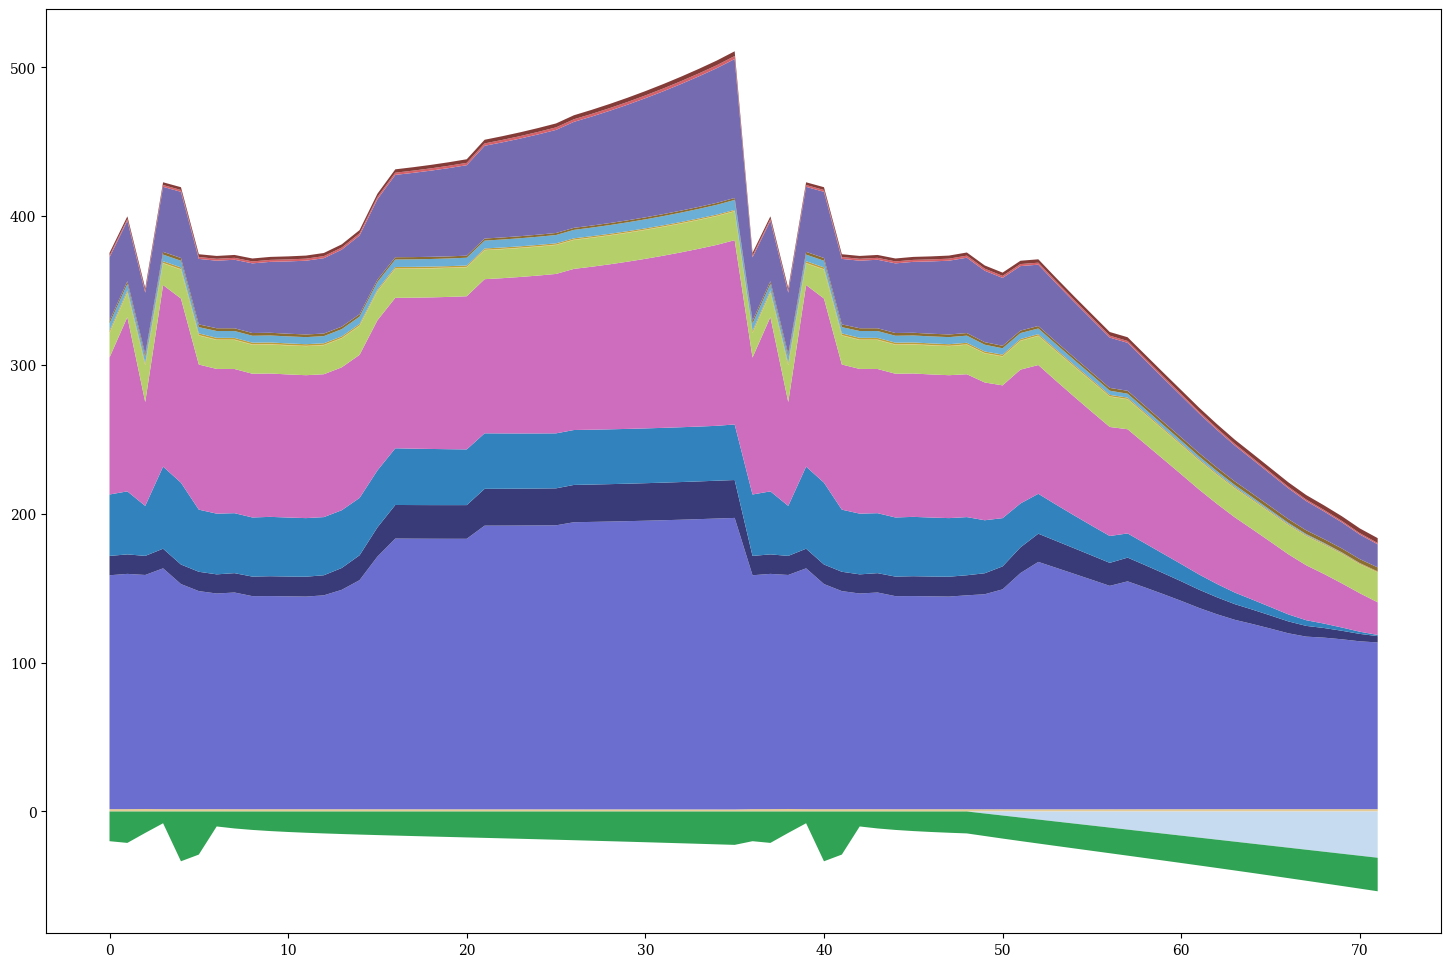

In [463]:
svp.plot_emissions_stack(
    df_out,
    ssp.model_attributes,
)

In [548]:
# read output
dfs_from_file = pd.read_csv(path_validation.joinpath("sisepuede_runs_20251118_5.10_future_1_pareto.csv"))




# build new dfs

df_prim_1 = ssp.odpt_primary.get_indexing_dataframe(dict_scens, )

dict_scens2 = {
    # we exclude future because we will run across all futures
    ssp.key_design: [0],
    ssp.key_future: list(range(1, df_l.shape[0] + 1)),
    ssp.key_strategy: [6004],
}
df_prim_2 = ssp.odpt_primary.get_indexing_dataframe(dict_scens2, )

df_prim = (
    pd.concat(
        [
            df_prim_1,
            df_prim_2
        ]
    )
    .sort_values(by = [ssp.key_primary])
    .reset_index(drop = True, )
)



def convert_indices(
    df_from_ssp0: pd.DataFrame,
    df_from_pareto0: pd.DataFrame,
    df_primary: pd.DataFrame,
    ssp: 'SISEPUEDE',
) -> pd.DataFrame:
    """Convert pareto indices to future ids
    """

    df_from_ssp = df_from_ssp0.copy()
    df_from_pareto = df_from_pareto0.copy()
    
    # convert indices
    pareto_indices = sorted(df_from_pareto[_FIELD_PARETO_INDEX].unique())
    prims_sorted = sorted(df_primary[ssp.key_primary].unique())
    dict_rnm_dfs = dict(zip(pareto_indices, prims_sorted, ))

    # reorder
    df_from_pareto[ssp.model_attributes.dim_region] = _REGION_NAME
    df_from_pareto[_FIELD_PARETO_INDEX] = df_from_pareto[_FIELD_PARETO_INDEX].replace(dict_rnm_dfs, )
    df_from_pareto = df_from_pareto.rename(columns = {_FIELD_PARETO_INDEX: ssp.key_primary}, )
    df_from_pareto = df_from_pareto.get(df_from_ssp.columns)
    
    # build output
    df_return = (
        pd.concat(
            [
                df_from_ssp,
                df_from_pareto,
            ]
        )
        .sort_values(by = [ssp.key_primary, ssp.model_attributes.dim_time_period])
        .reset_index(drop = True, )
    )

    return df_return


# run the function
df_exp_in = convert_indices(
    df_in,
    dfs_in,
    df_prim_2,
    ssp,
)

df_exp_out = convert_indices(
    df_out,
    dfs_out,
    df_prim_2,
    ssp,
)


df_exp_wide = (
    pd.merge(
        df_exp_in,
        df_exp_out,
        how = "inner",
    )
    .sort_values(
        by = [ssp.key_primary, ssp.model_attributes.dim_time_period]
    )
    .reset_index(drop = True, )
)






In [671]:
fields = [x for x in df_exp_wide.columns if x.startswith("emission_co2e_subsector")]

field_primary = ssp.key_primary
field_time_period = ssp.model_attributes.dim_time_period
field_total = "emission_co2e_net"
field_technical_cost = "technical_cost"

df_exp_wide2 = df_exp_wide.copy()
df_exp_wide2[field_total] = df_exp_wide2[fields].sum(axis = 1)

df_check = (
    df_exp_wide2[
        df_exp_wide2[field_time_period].isin(range(31, 36))
    ][
        [field_primary, field_total]
    ]
    .groupby([field_primary])
    .mean()
    .reset_index()
)

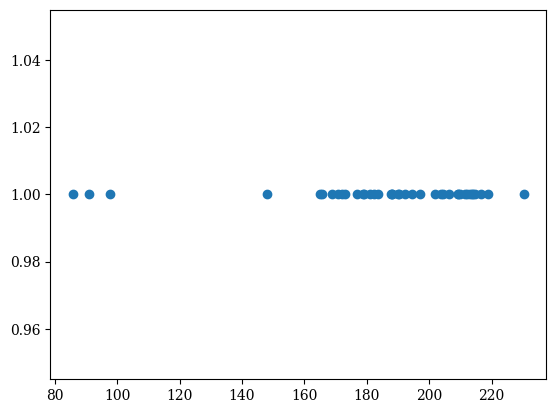

In [572]:
vec = df_check[
    df_check[field_total] < 10000
][field_total].iloc[1:].to_numpy()

plt.scatter(vec, np.ones(vec.shape))



In [588]:
path_write = path_validation.joinpath(f"{ssp.analysis_id.id_fs_safe}_PARETO5.11")
if not path_write.is_dir():
    os.makedirs(path_write, exist_ok = True, )
fp_out_adj = path_write.joinpath("sisepuede_runs_20251119_5.11_future_1_pareto_with_baselines.csv")
fp_out_prim = path_write.joinpath("ATTRIBUTE_PRIMARY.csv")
fp_out_strat = path_write.joinpath("ATTRIBUTE_STRATEGY.csv")


sf._write_csv(
    strategies.attribute_table.table,
    fp_out_strat
)

sf._write_csv(
    df_prim,
    fp_out_prim
)


sf._write_csv(
    df_exp_wide,
    fp_out_adj
)





True

Text(0, 0.5, 'LHC Trial')

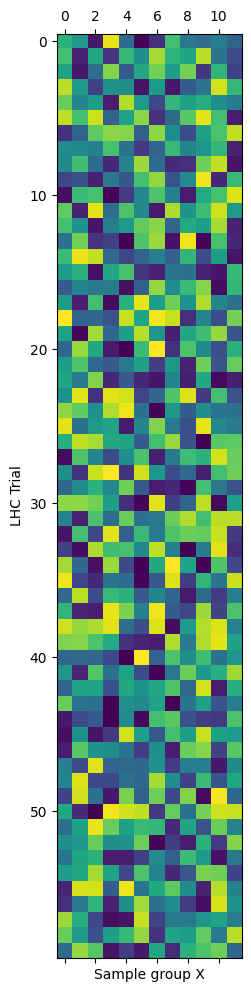

In [714]:
fig, ax = plt.subplots(figsize = (100, 12))
fields_l = [x for x in dict_training_data.get("fields_x") if x not in fields_trajgroups_x]
fields_trajgroups_x
ax.matshow(
    df_train[fields_trajgroups_x].iloc[0:60],
)

ax.set_xlabel("Sample group X")
ax.set_ylabel("LHC Trial")


In [740]:
import matplotlib
matplotlib.colormaps()

['magma',
 'inferno',
 'plasma',
 'viridis',
 'cividis',
 'twilight',
 'twilight_shifted',
 'turbo',
 'Blues',
 'BrBG',
 'BuGn',
 'BuPu',
 'CMRmap',
 'GnBu',
 'Greens',
 'Greys',
 'OrRd',
 'Oranges',
 'PRGn',
 'PiYG',
 'PuBu',
 'PuBuGn',
 'PuOr',
 'PuRd',
 'Purples',
 'RdBu',
 'RdGy',
 'RdPu',
 'RdYlBu',
 'RdYlGn',
 'Reds',
 'Spectral',
 'Wistia',
 'YlGn',
 'YlGnBu',
 'YlOrBr',
 'YlOrRd',
 'afmhot',
 'autumn',
 'binary',
 'bone',
 'brg',
 'bwr',
 'cool',
 'coolwarm',
 'copper',
 'cubehelix',
 'flag',
 'gist_earth',
 'gist_gray',
 'gist_heat',
 'gist_ncar',
 'gist_rainbow',
 'gist_stern',
 'gist_yarg',
 'gnuplot',
 'gnuplot2',
 'gray',
 'hot',
 'hsv',
 'jet',
 'nipy_spectral',
 'ocean',
 'pink',
 'prism',
 'rainbow',
 'seismic',
 'spring',
 'summer',
 'terrain',
 'winter',
 'Accent',
 'Dark2',
 'Paired',
 'Pastel1',
 'Pastel2',
 'Set1',
 'Set2',
 'Set3',
 'tab10',
 'tab20',
 'tab20b',
 'tab20c',
 'grey',
 'gist_grey',
 'gist_yerg',
 'Grays',
 'magma_r',
 'inferno_r',
 'plasma_r',
 'viri

Text(0, 0.5, 'Minimum Share of Production by Technology')

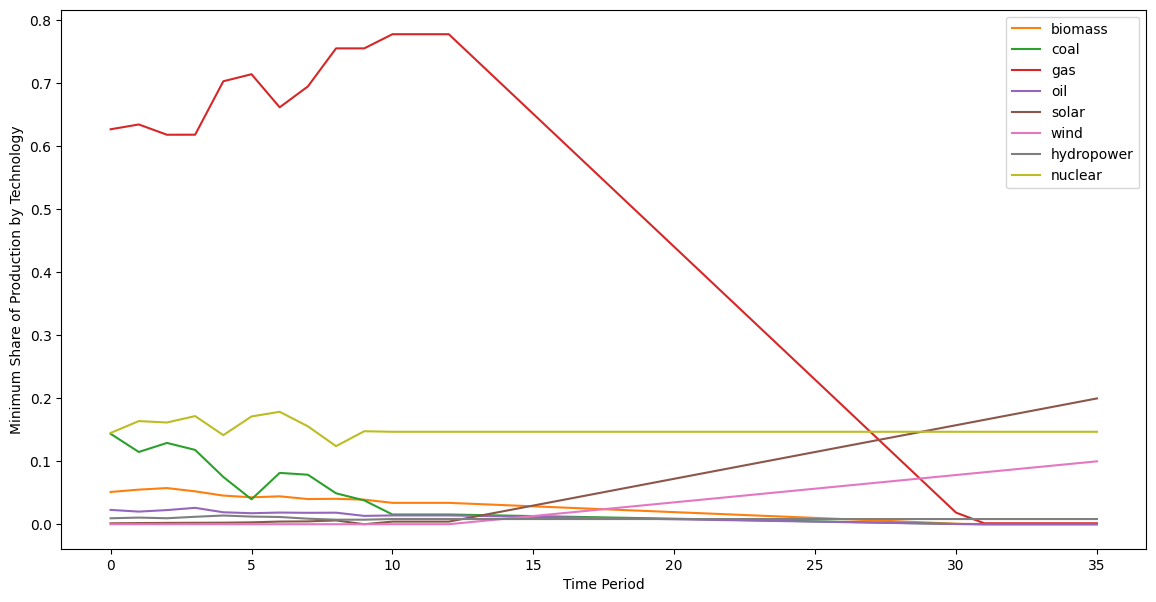

In [770]:
plt.style.use("default", )
plt.style.use("tableau-colorblind10", )
fields_plot = [x for x in dfs_in.columns if ("min_share_" in x) and ("pp" in x) and (dfs_in[x].max() > 0)]
dfs_plot = dfs_in[[_FIELD_PARETO_INDEX, field_time_period] + fields_plot]

# setup plot
cmap = plt.get_cmap("tab20")
fig, ax = plt.subplots(figsize = (14, 7))

for j, fld in enumerate(fields_plot):
    (
        df[[field_time_period, fld]]
        .rename(
            columns = {
                fld: fld.replace("nemomod_entc_frac_min_share_production_pp_", "")
            }
        )
        .plot(
            x = field_time_period,
            ax = ax,
            color = cmap((j + 1)/10),
        )
    )

ax.set_xlabel("Time Period")
ax.set_ylabel("Minimum Share of Production by Technology")




Text(0, 0.5, 'Minimum Share of Production by Technology')

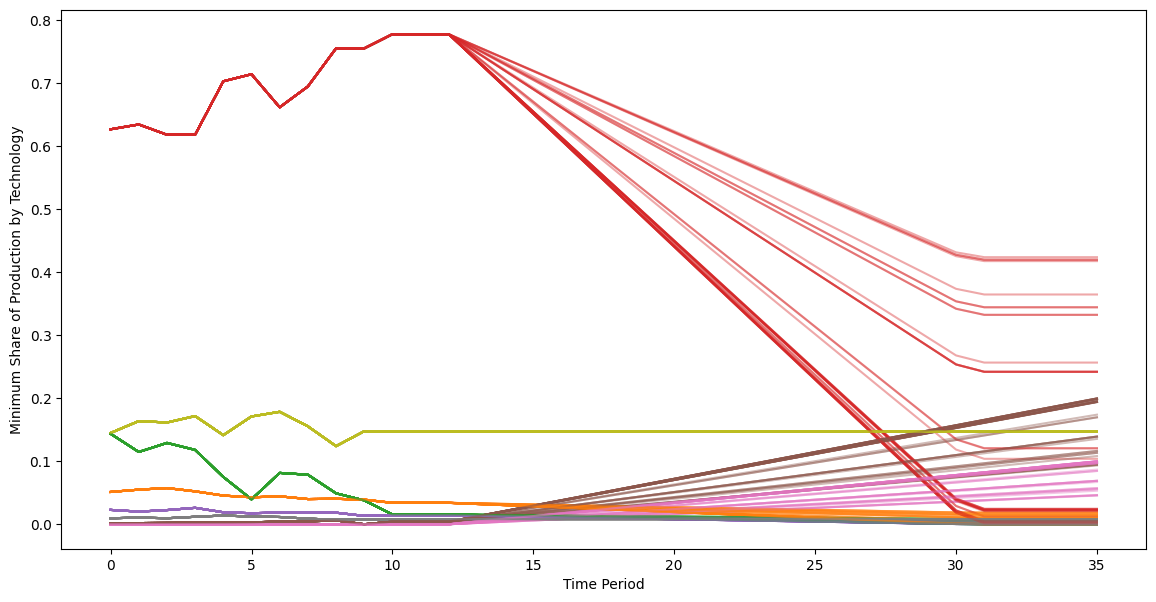

In [774]:
plt.style.use("default", )
plt.style.use("tableau-colorblind10", )
fields_plot = [x for x in dfs_in.columns if ("min_share_" in x) and ("pp" in x) and (dfs_in[x].max() > 0)]
dfs_plot = dfs_in[[_FIELD_PARETO_INDEX, field_time_period] + fields_plot]

# setup plot
cmap = plt.get_cmap("tab20")
fig, ax = plt.subplots(figsize = (14, 7))

dfg = dfs_plot.groupby([_FIELD_PARETO_INDEX])
for i, df in dfg:

    for j, fld in enumerate(fields_plot):
        (
            df[[field_time_period, fld]]
            .plot(
                x = field_time_period,
                alpha = 0.4,
                ax = ax,
                color = cmap((j + 1)/10),
                legend = False,
            )
        )

ax.set_xlabel("Time Period")
ax.set_ylabel("Minimum Share of Production by Technology")





# Read in decomposed

In [667]:
path_cb = path_write.joinpath("combined_cb_results_2025-11-16T10;43;25.118223.csv")
path_ide = path_write.joinpath("sisepuede_results_IDE_2025-11-16T10;43;25.118223.csv")

df_cb = pd.read_csv(path_cb, )
df_cb[field_time_period] = df_cb[field_time_period].astype(int)
df_ide = pd.read_csv(path_ide, )


<Axes: xlabel='emissions_total', ylabel='technical_cost'>

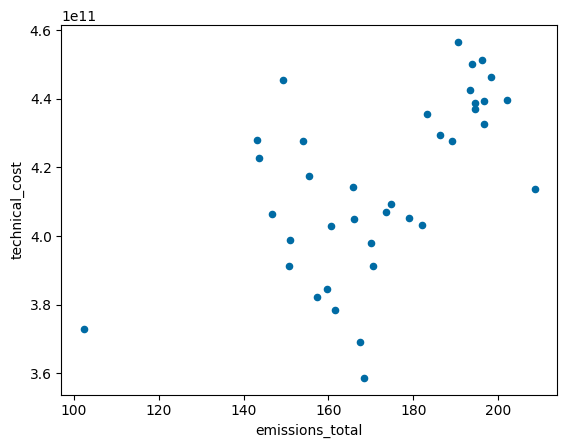

In [682]:
field_future = ssp.key_future
field_primary = ssp.key_primary
field_technical_cost = "technical_cost"
field_time_period = ssp.model_attributes.dim_time_period
field_total = "emission_co2e_net"
field_value = "value"


df_cb_merge = (
    df_cb
    .get([field_primary, field_value])
    .groupby([field_primary])
    .sum()
    .reset_index()
    .sort_values(by = [field_primary])
    .rename(columns = {field_value: "technical_cost"})
)


df_check = (
    df_ide[
        df_ide[field_time_period].isin(range(31, 36))
    ][
        [field_primary, "emissions_total"]
    ]
    .groupby([field_primary])
    .mean()
    .reset_index()
)


df_cb_merge = pd.merge(
    df_cb_merge,
    df_check,
)

df_cb_merge.plot.scatter(
    x = "emissions_total",
    y = "technical_cost"
)

In [658]:
df_ide["emissions_total"]



0       192.501062
1       202.528241
2       206.804491
3       212.515644
4       216.453965
           ...    
1135    161.070972
1136    160.689357
1137    160.481894
1138    160.376049
1139    155.786689
Name: emissions_total, Length: 1140, dtype: float64

In [652]:
fields = [x for x in df_exp_wide.columns if x.startswith("emission_co2e_subsector")]

field_primary = ssp.key_primary
field_time_period = ssp.model_attributes.dim_time_period
field_total = "emission_co2e_net"


In [300]:
path_write = path_validation.joinpath(ssp.analysis_id.id_fs_safe)
fp_out_adj = path_write.joinpath("sisepuede_runs_20251118_5.10_future_1_pareto_with_baselines.csv")
fp_out_prim = path_write.joinpath("ATTRIBUTE_PRIMARY.csv")

if not path_write.is_dir():
    os.makedirs(path_write, exist_ok = True, )
    
sf._write_csv(df_exp, fp_out_adj, )
sf._write_csv(df_prim, fp_out_prim, )


True

(array([8., 7., 4., 3., 2., 4., 5., 2., 2., 3.]),
 array([ 22.89716148,  32.98240795,  43.06765442,  53.15290089,
         63.23814735,  73.32339382,  83.40864029,  93.49388676,
        103.57913322, 113.66437969, 123.74962616]),
 <BarContainer object of 10 artists>)

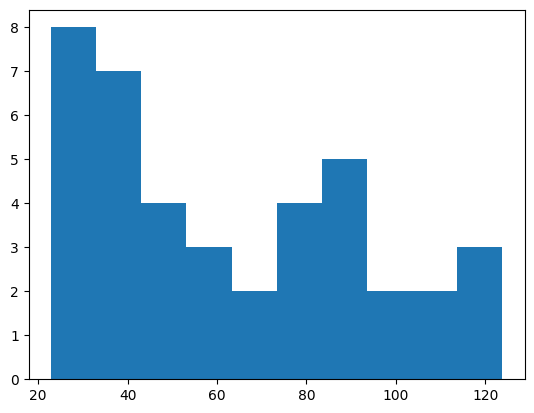

In [303]:
plt.hist(df_frontier["emission_avg_last_five_years"])

In [247]:
path_cur = pathlib.Path(os.path.abspath(os.path.curdir))
path_validation = path_cur.parents[0].joinpath("validation")
if not path_validation.is_dir():
    os.makedirs(path_validation, exist_ok = True, )

In [248]:
sf._write_csv(dfs, path_validation.joinpath("sisepuede_runs_20251118_5.10_future_1_pareto.csv"))

True

<Axes: xlabel='emission_avg_last_five_years', ylabel='technical_cost'>

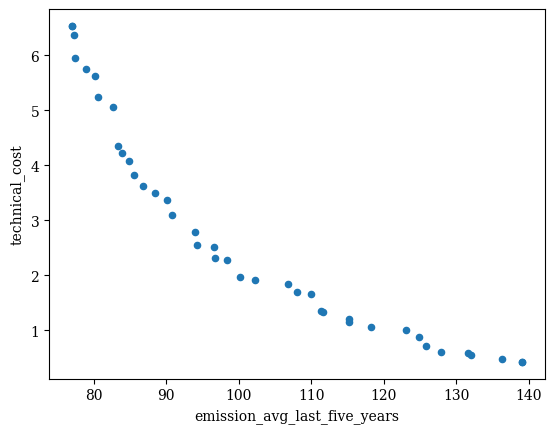

In [573]:
df_frontier[["emission_avg_last_five_years", "technical_cost"]].plot.scatter(x = "emission_avg_last_five_years", y = "technical_cost")

In [ ]:
fig, ax = plt.subplots(figsize = (10, 10))

# get labels
labels_y = problem.labels_y
ax.set_xlabel(labels_y[0], fontfamily = "IBM Plex Sans", fontsize = 14, )
ax.set_ylabel(labels_y[1], fontfamily = "IBM Plex Sans", fontsize = 14, )


dfg = df_pareto_frontiers.groupby([_FIELD_FUTURE_ID])
for fut, df in dfg:
    
    ax.scatter(
        df[labels_y[0]], 
        df[labels_y[1]], 
        #facecolor = "none",
        #edgecolor = "red",
        label = f"{_FIELD_FUTURE_ID} = {fut[0]}",
        s = 50,
    )

ax.legend()


In [100]:
dir(lhs_design)
lhs_design.fields_factors_x

[46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59]

In [107]:
su = futures.dict_sampling_units.get(59)


In [83]:
4lhs_design.fields_factors_x

[46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59]

In [85]:
lhs_design.fields_factors_l

[1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 1714,
 1715,
 1718,
 1720,
 1723,
 1740,
 1741,
 1744,
 1747,
 1749,
 1761,
 1762,
 1767,
 1768,
 1770,
 1778,
 1780,
 1792,
 1793,
 1801]